# NYSE TAQ Analysis: Complete Results Summary

This notebook consolidates all the TAQ analysis scripts, their outputs, plots, and results into one readable document.

## Scripts in this folder

| Script | Purpose |
|---|---|
| `taq_feature_engineering.py` | Build 1-minute BBO and trade feature bars |
| `taq_consolidated_trades_analysis.py` | Build full-day trade bars from consolidated file |
| `taq_advanced_features.py` | Predict volatility and direction from microstructure features |
| `taq_predictive_analysis.py` | Test 5-second bar features for return prediction |
| `taq_microstructure_signal.py` | Test depth imbalance as directional signal |

## Output files

| File | Description |
|---|---|
| `taq_bbo_features.csv` | 14K rows of 1-minute BBO features (6 symbols) |
| `taq_trade_features.csv` | Aggregate trade stats per symbol |
| `taq_consolidated_trade_bars.csv` | 5.7K rows of 1-minute OHLCV bars (6 symbols) |
| `taq_advanced_summary.csv` | Volatility/direction prediction scores |
| `taq_predictive_summary.csv` | 5-second bar return prediction scores |

In [1]:
import pandas as pd
import numpy as np
from IPython.display import Image, display
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)

FOLDER = Path('.')

---
## Part 1: Basic Feature Engineering (`taq_feature_engineering.py`)

This script parses the NYSE BBO file (`EQY_US_TAQ_NYSE_BBO_1_20231002.gz`) and NYSE trades file (`EQY_US_TAQ_NYSE_TRADES_20231002.gz`), then builds 1-minute feature bars.

### BBO features built:
- **Spread (bps)** — bid-ask spread in basis points
- **Quote intensity** — number of NBBO updates per minute
- **Depth imbalance** — (bid_sz - ask_sz) / (bid_sz + ask_sz)
- **Quoted depth** — total shares at best bid + ask
- **Mid-price returns** — log return of (bid+ask)/2 within each minute

### Trade features built:
- Total volume, trade count, average trade size
- VWAP, price std, min/max price
- Sale condition breakdown

In [2]:
bbo_features = pd.read_csv(FOLDER / 'taq_bbo_features.csv')
print(f'BBO features: {len(bbo_features):,} rows, {bbo_features["symbol"].nunique()} symbols')
print(f'Symbols: {sorted(bbo_features["symbol"].unique())}')
print()
print('Sample rows:')
bbo_features.head(10)

BBO features: 14,036 rows, 6 symbols
Symbols: ['AAPL', 'AMZN', 'DIA', 'GOOGL', 'IVV', 'IWM']

Sample rows:


,symbol,minute,nbbo_updates,mean_spread_bps,median_spread_bps,max_spread_bps,mean_depth_imbalance,mean_quoted_depth,first_mid,last_mid,high_mid,low_mid,mid_return,mid_range,quote_intensity
0,AAPL,07:48:32,1,126.442782,126.442782,126.442782,0.0,200.0,172.410,172.410,172.410,172.410,0.000000,0.000000,1
1,AAPL,07:50:46,1,123.524806,123.524806,123.524806,0.0,200.0,172.435,172.435,172.435,172.435,0.000000,0.000000,1
2,AAPL,07:50:48,1,123.524806,123.524806,123.524806,0.0,200.0,172.435,172.435,172.435,172.435,0.000000,0.000000,1
3,AAPL,07:56:39,1,117.691393,117.691393,117.691393,0.0,200.0,172.485,172.485,172.485,172.485,0.000000,0.000000,1
4,AAPL,08:00:00,1,114.192969,114.192969,114.192969,0.0,200.0,172.515,172.515,172.515,172.515,0.000000,0.000000,1
5,AAPL,08:00:01,1,113.027098,113.027098,113.027098,0.0,200.0,172.525,172.525,172.525,172.525,0.000000,0.000000,1
6,AAPL,08:22:34,1,139.876375,139.876375,139.876375,0.0,200.0,172.295,172.295,172.295,172.295,0.000000,0.000000,1
7,AAPL,08:24:02,1,137.538810,137.538810,137.538810,0.0,200.0,172.315,172.315,172.315,172.315,0.000000,0.000000,1
8,AAPL,08:30:45,5,89.294610,136.370231,136.954503,0.0,200.0,172.320,171.305,172.325,171.295,-0.005908,59.772516,5
9,AAPL,08:30:46,22,77.789333,78.689926,136.954503,0.0,200.0,172.325,171.305,172.330,171.305,-0.005937,59.480633,22


In [3]:
print('BBO feature summary by symbol:')
bbo_summary = bbo_features.groupby('symbol').agg(
    avg_spread_bps=('mean_spread_bps', 'mean'),
    avg_quote_intensity=('quote_intensity', 'mean'),
    avg_depth_imbalance=('mean_depth_imbalance', 'mean'),
    mid_return_std=('mid_return', 'std'),
    n_minutes=('symbol', 'count'),
).round(2)
bbo_summary

BBO feature summary by symbol:


,avg_spread_bps,avg_quote_intensity,avg_depth_imbalance,mid_return_std,n_minutes
symbol,,,,,
AAPL,112.15,22.09,-0.01,0.01,1748
AMZN,137.42,25.22,0.01,0.01,1161
DIA,16.24,10.30,-0.02,0.00,3562
GOOGL,113.60,21.61,-0.10,0.01,943
IVV,16.58,12.01,0.03,0.00,3291
IWM,9.57,10.60,-0.02,0.00,3331


In [4]:
trade_features = pd.read_csv(FOLDER / 'taq_trade_features.csv')
print('Trade features (aggregate per symbol):')
trade_features[['symbol', 'total_volume', 'trade_count', 'avg_trade_size', 'vwap_approx']]

Trade features (aggregate per symbol):


,symbol,total_volume,trade_count,avg_trade_size,vwap_approx
0,AAPL,100,1,100.0,171.21
1,AMZN,100,1,100.0,127.12
2,DIA,100,1,100.0,334.95
3,GOOGL,100,1,100.0,130.86
4,IVV,100,1,100.0,429.43
5,IWM,100,1,100.0,176.74


### Overview plot

This 4-panel figure shows:
1. **Top-left:** Spread dynamics (bps) by symbol over hour 1 — how tight/wide spreads are
2. **Top-right:** Average quote intensity (updates per minute) — which symbols have the most active quoting
3. **Bottom-left:** Depth imbalance distribution — whether bid or ask side tends to be heavier
4. **Bottom-right:** Cumulative realized variance — how volatility accumulates through the hour

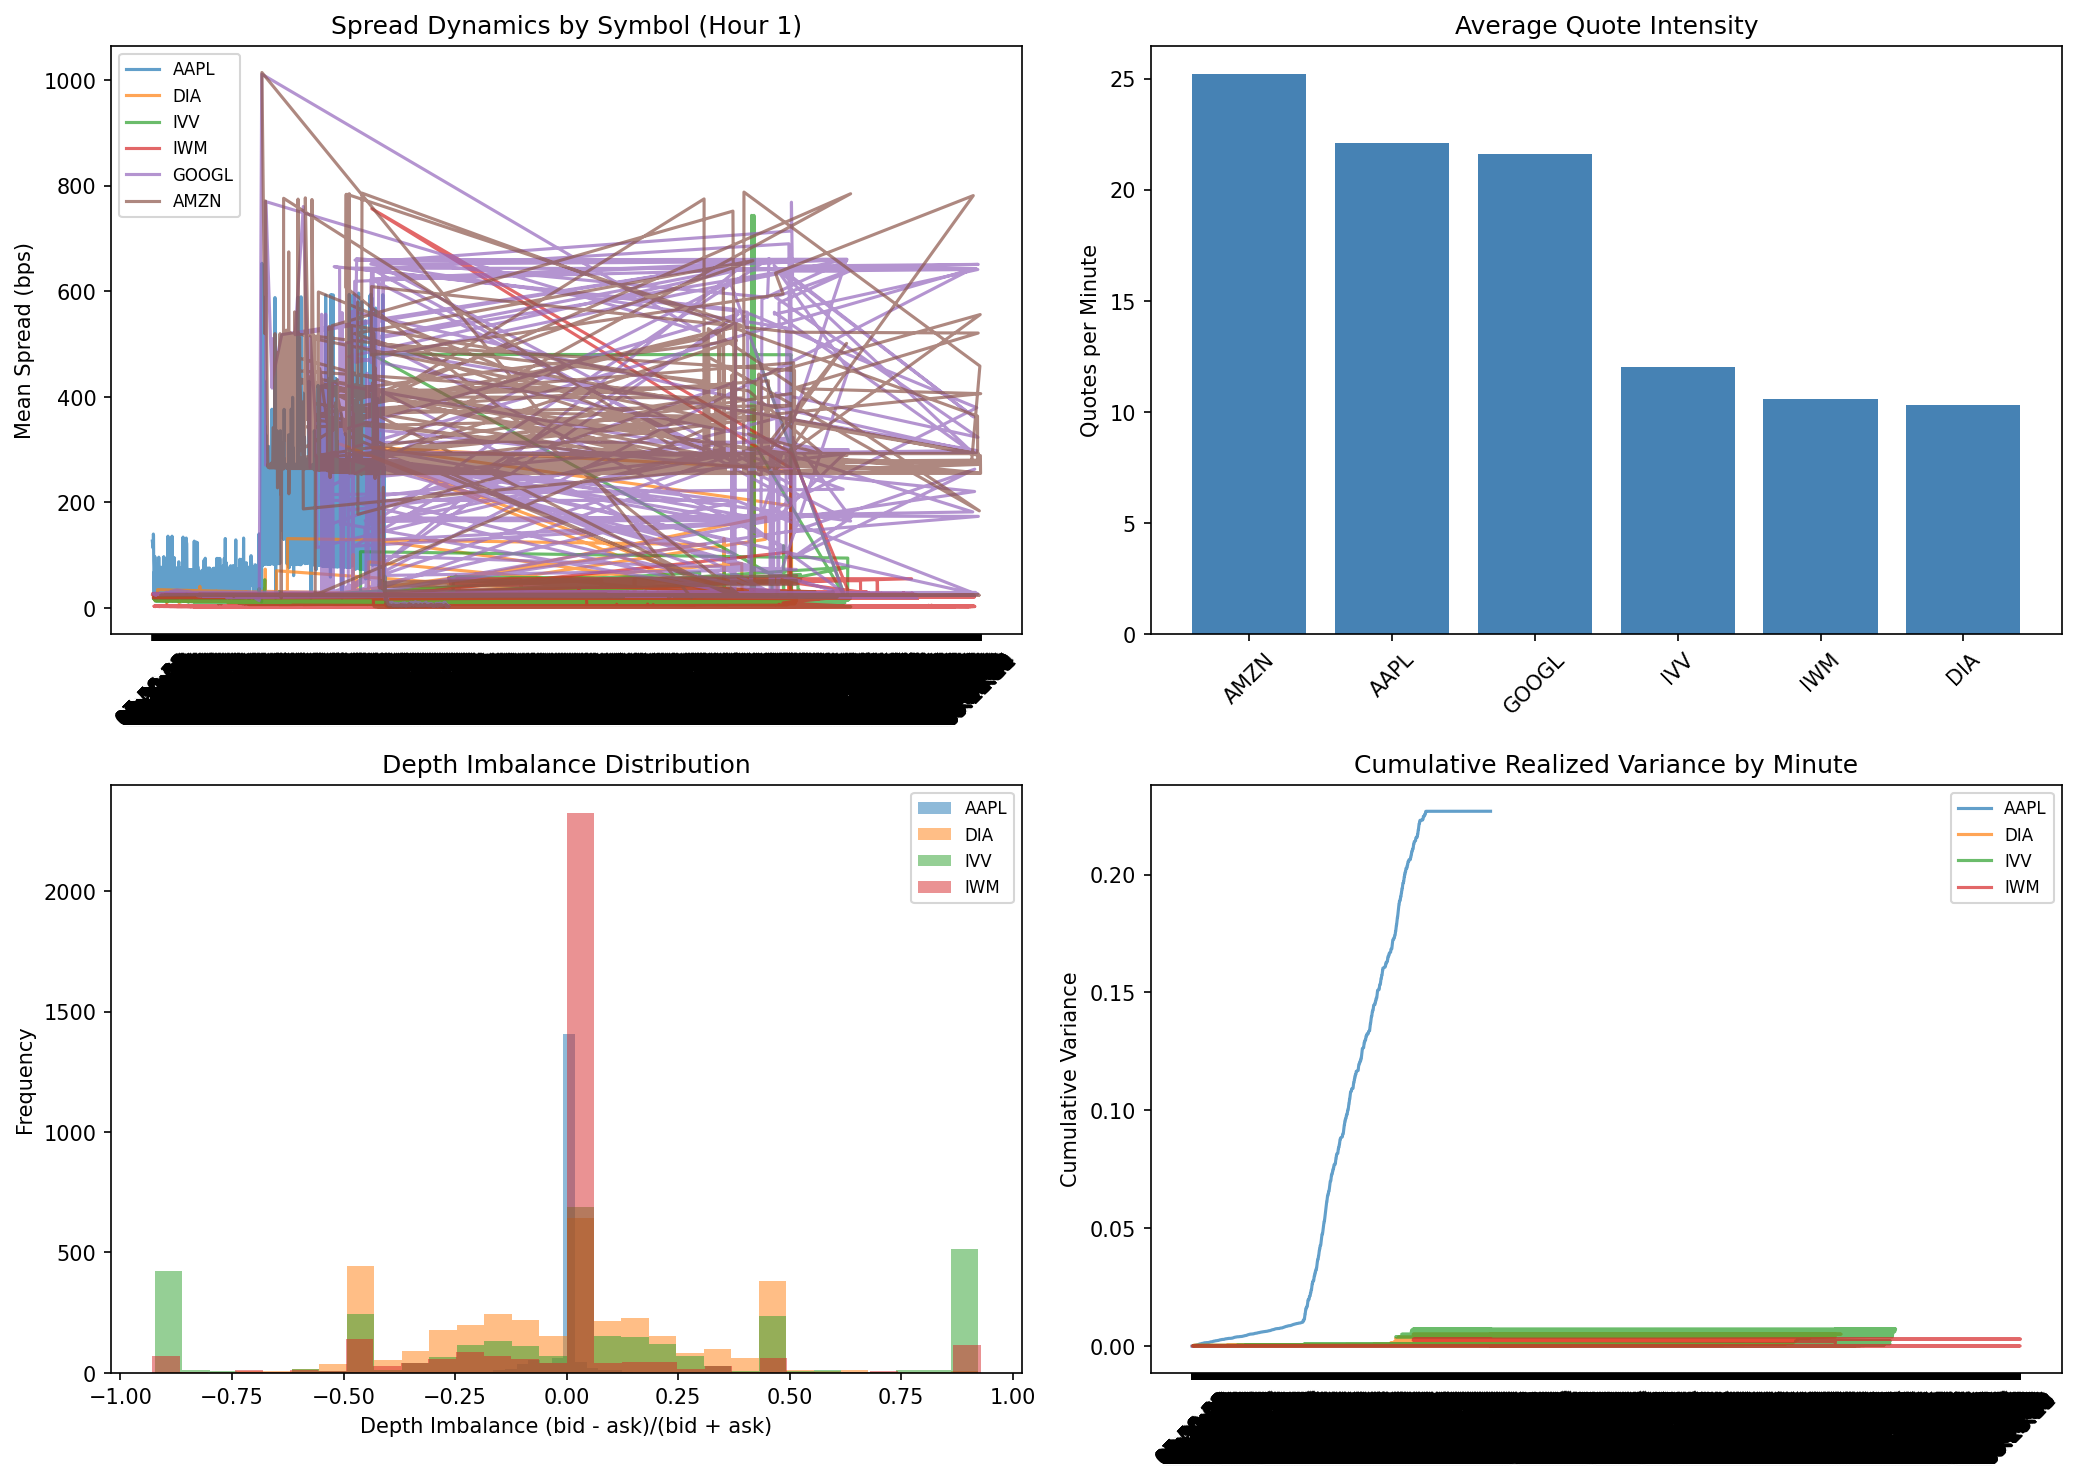

In [5]:
display(Image(filename=str(FOLDER / 'taq_features_overview.png')))

---
## Part 2: Full-Day Consolidated Trade Bars (`taq_consolidated_trades_analysis.py`)

This script parses the full-day consolidated trades file (`EQY_US_ALL_TRADE_20260102.gz`) for 6 symbols and builds 1-minute OHLCV bars.

### Features built:
- Total volume, trade count, average trade size
- OHLC prices (open/high/low/close per minute)
- VWAP (volume-weighted average price)
- Minute return, realized variance, dollar volume

This is the same data used in the `NYSE_TAQ_Consolidated_Trades_Exploration.ipynb` notebook.

In [6]:
trade_bars = pd.read_csv(FOLDER / 'taq_consolidated_trade_bars.csv')
print(f'Consolidated trade bars: {len(trade_bars):,} rows, {trade_bars["symbol"].nunique()} symbols')
print(f'Symbols: {sorted(trade_bars["symbol"].unique())}')
print()
print('Daily summary:')
daily = trade_bars.groupby('symbol').agg(
    total_volume=('total_volume', 'sum'),
    total_trades=('trade_count', 'sum'),
    vwap=('vwap', lambda x: np.average(x, weights=trade_bars.loc[x.index, 'total_volume'])),
    open_price=('open_price', 'first'),
    close_price=('close_price', 'last'),
    realized_var=('realized_var', 'sum'),
).reset_index()
daily['daily_return_pct'] = 100 * np.log(daily['close_price'] / daily['open_price'])
daily['realized_vol'] = np.sqrt(daily['realized_var'])
daily.round(4)

Consolidated trade bars: 5,698 rows, 6 symbols
Symbols: ['AAPL', 'IWM', 'MSFT', 'QQQ', 'SPY', 'TSLA']

Daily summary:


,symbol,total_volume,total_trades,vwap,open_price,close_price,realized_var,daily_return_pct,realized_vol
0,AAPL,48835599,642197,271.7274,272.17,270.9607,0.0002,-0.4453,0.0151
1,IWM,42081335,351337,247.6820,247.70,248.7800,0.0002,0.4351,0.0156
2,MSFT,29352772,716532,474.4126,487.00,473.3000,0.0098,-2.8535,0.0990
3,QQQ,62536678,1088614,614.8996,617.38,613.6900,0.0001,-0.5995,0.0121
4,SPY,93459938,1251790,682.9801,685.32,683.1700,0.0001,-0.3142,0.0093
5,TSLA,89922555,1865256,443.8648,458.63,441.4900,0.0006,-3.8088,0.0250


### Full-day trade profile plot

This 4-panel figure shows the intraday profile for 6 symbols:
1. **Top-left:** Volume profile — the classic U-shape (high at open and close, lower midday)
2. **Top-right:** Trade count profile — how many prints per minute
3. **Bottom-left:** Volatility signature — realized variance by time of day
4. **Bottom-right:** Average trade size profile — how trade sizes evolve through the day

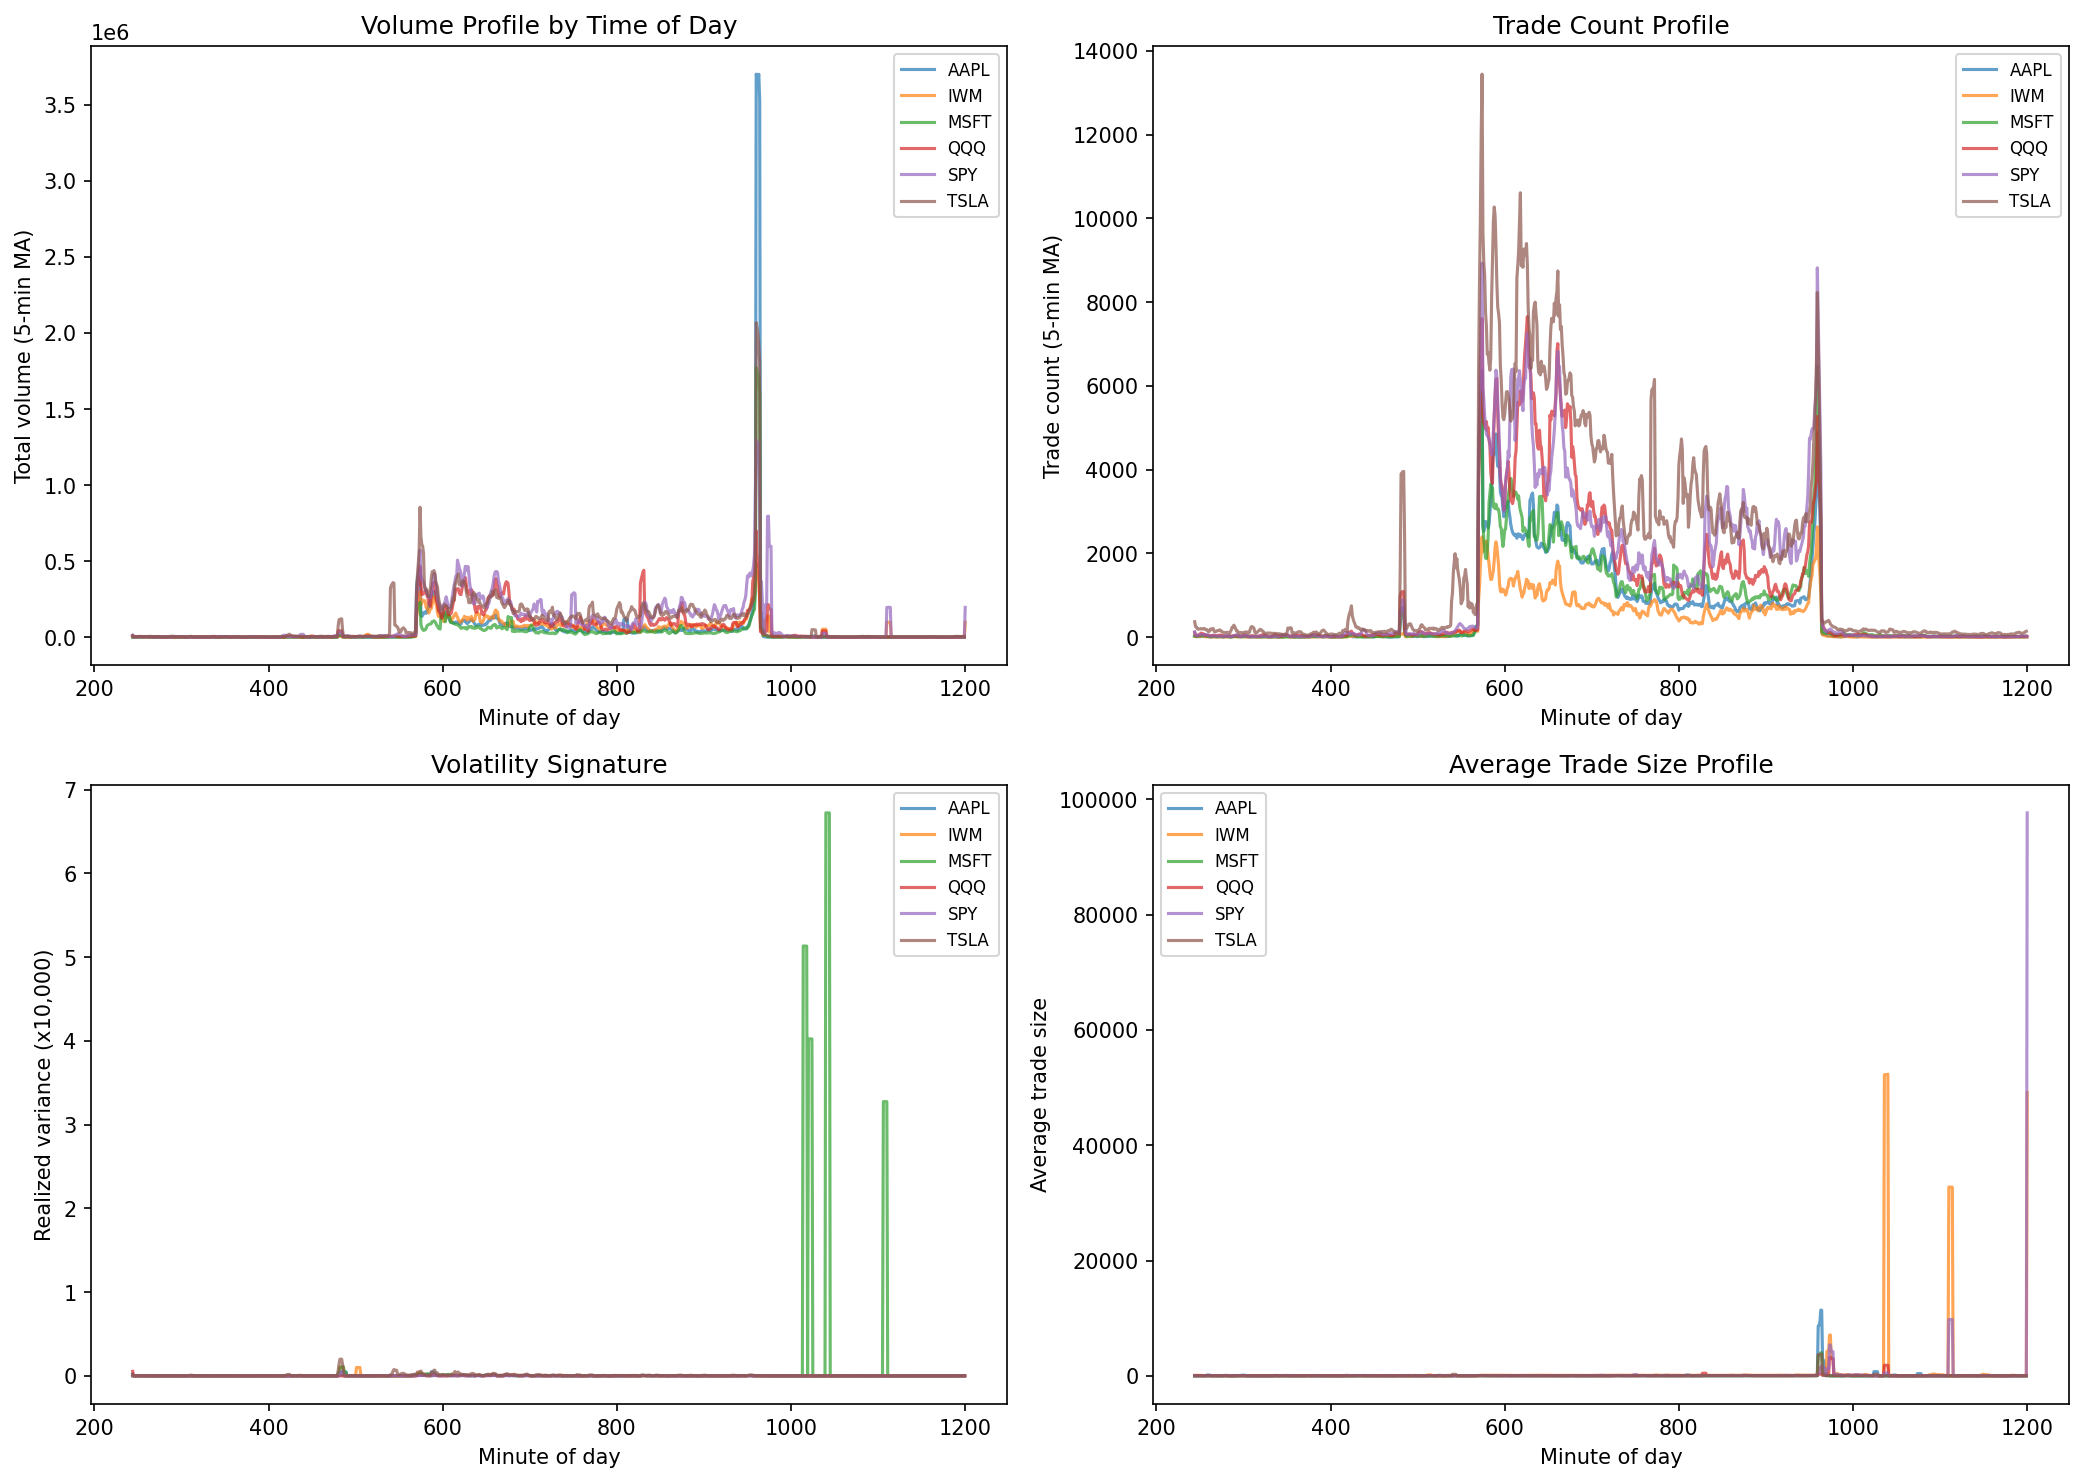

In [7]:
display(Image(filename=str(FOLDER / 'taq_full_day_trade_profile.png')))

---
## Part 3: Advanced Features — Volatility & Direction Prediction (`taq_advanced_features.py`)

This script builds on the 1-minute BBO bars and adds:
- **Lag features** (lag1, lag5) for all microstructure features
- **Rolling volatility** (5-min, 10-min windows)
- **Forward labels**: next-5-minute realized variance (volatility target) and next-minute return sign (direction target)

### Two prediction tasks:
1. **Volatility prediction** — Ridge regression to predict forward 5-min realized variance
2. **Direction prediction** — Logistic regression to predict whether next-minute return is positive

### Features used:
- `realized_var_lag1`, `realized_var_lag5` — recent volatility
- `vol_5`, `vol_10` — rolling volatility
- `mean_spread_bps_lag1` — recent spread
- `mean_depth_imbalance_lag1` — recent order flow pressure
- `quote_intensity_lag1` — recent quoting activity
- `mean_log_depth_lag1` — recent depth
- `min_range_lag1` — recent price range

In [8]:
advanced = pd.read_csv(FOLDER / 'taq_advanced_summary.csv')

vol = advanced[advanced['task'] == 'volatility'][['symbol', 'r2_train', 'r2_test', 'n_test']]
print('=== Volatility Prediction (Ridge Regression) ===')
print('Target: sum of next 5 minutes of realized variance')
print()
print(vol.to_string(index=False))
print()
print('Interpretation:')
print('  - R² train is positive for all symbols (0.04 to 0.85) — features carry signal')
print('  - R² test is very negative — severe overfitting with only ~130-155 test points')
print('  - This is a proof of concept: we need more data (more days) for stable test performance')

=== Volatility Prediction (Ridge Regression) ===
Target: sum of next 5 minutes of realized variance

symbol  r2_train       r2_test  n_test
  AAPL  0.695019   -135.748336     132
   DIA  0.104716     -0.774291     144
   IVV  0.384748   -510.714970     144
   IWM  0.039901   -436.212507     155
 GOOGL  0.654873 -12260.831544     127
  AMZN  0.851297  -4731.975701     127

Interpretation:
  - R² train is positive for all symbols (0.04 to 0.85) — features carry signal
  - R² test is very negative — severe overfitting with only ~130-155 test points
  - This is a proof of concept: we need more data (more days) for stable test performance


In [9]:
direction = advanced[advanced['task'] == 'direction'][['symbol', 'train_acc', 'test_acc', 'auc', 'baseline', 'n_test']]
print('=== Direction Prediction (Logistic Regression) ===')
print('Target: sign of next-minute return (up or down)')
print()
print(direction.to_string(index=False))
print()
print('Interpretation:')
print('  - Baseline = accuracy of always predicting the majority class')
print('  - AAPL: 51.5% vs 50.7% baseline — slight edge')
print('  - IWM: 54.8% vs 53.5% baseline — slight edge')
print('  - Others: at or below baseline — no clear signal with this little data')
print('  - AUC near 0.5 means the model is basically guessing')

=== Direction Prediction (Logistic Regression) ===
Target: sign of next-minute return (up or down)

symbol  train_acc  test_acc      auc  baseline  n_test
  AAPL   0.569132  0.514925 0.531640  0.507463     134
   DIA   0.555882  0.445205 0.426103  0.513699     146
   IVV   0.570588  0.517007 0.470163  0.517007     147
   IWM   0.578082  0.547771 0.516145  0.535032     157
 GOOGL   0.558140  0.410853 0.444148  0.550388     129
  AMZN   0.574751  0.446154 0.457751  0.500000     130

Interpretation:
  - Baseline = accuracy of always predicting the majority class
  - AAPL: 51.5% vs 50.7% baseline — slight edge
  - IWM: 54.8% vs 53.5% baseline — slight edge
  - Others: at or below baseline — no clear signal with this little data
  - AUC near 0.5 means the model is basically guessing


### Per-symbol advanced plots

Each plot has 4 panels:
1. **Top-left:** Mid price (black, left axis) and spread in bps (red, right axis) over time
2. **Top-right:** 5-minute rolling realized variance — volatility clustering visible
3. **Bottom-left:** Predicted vs actual volatility (scatter) — how well the Ridge model fits
4. **Bottom-right:** Feature importance (Ridge coefficients) — which features matter most


=== AAPL — Advanced Features ===


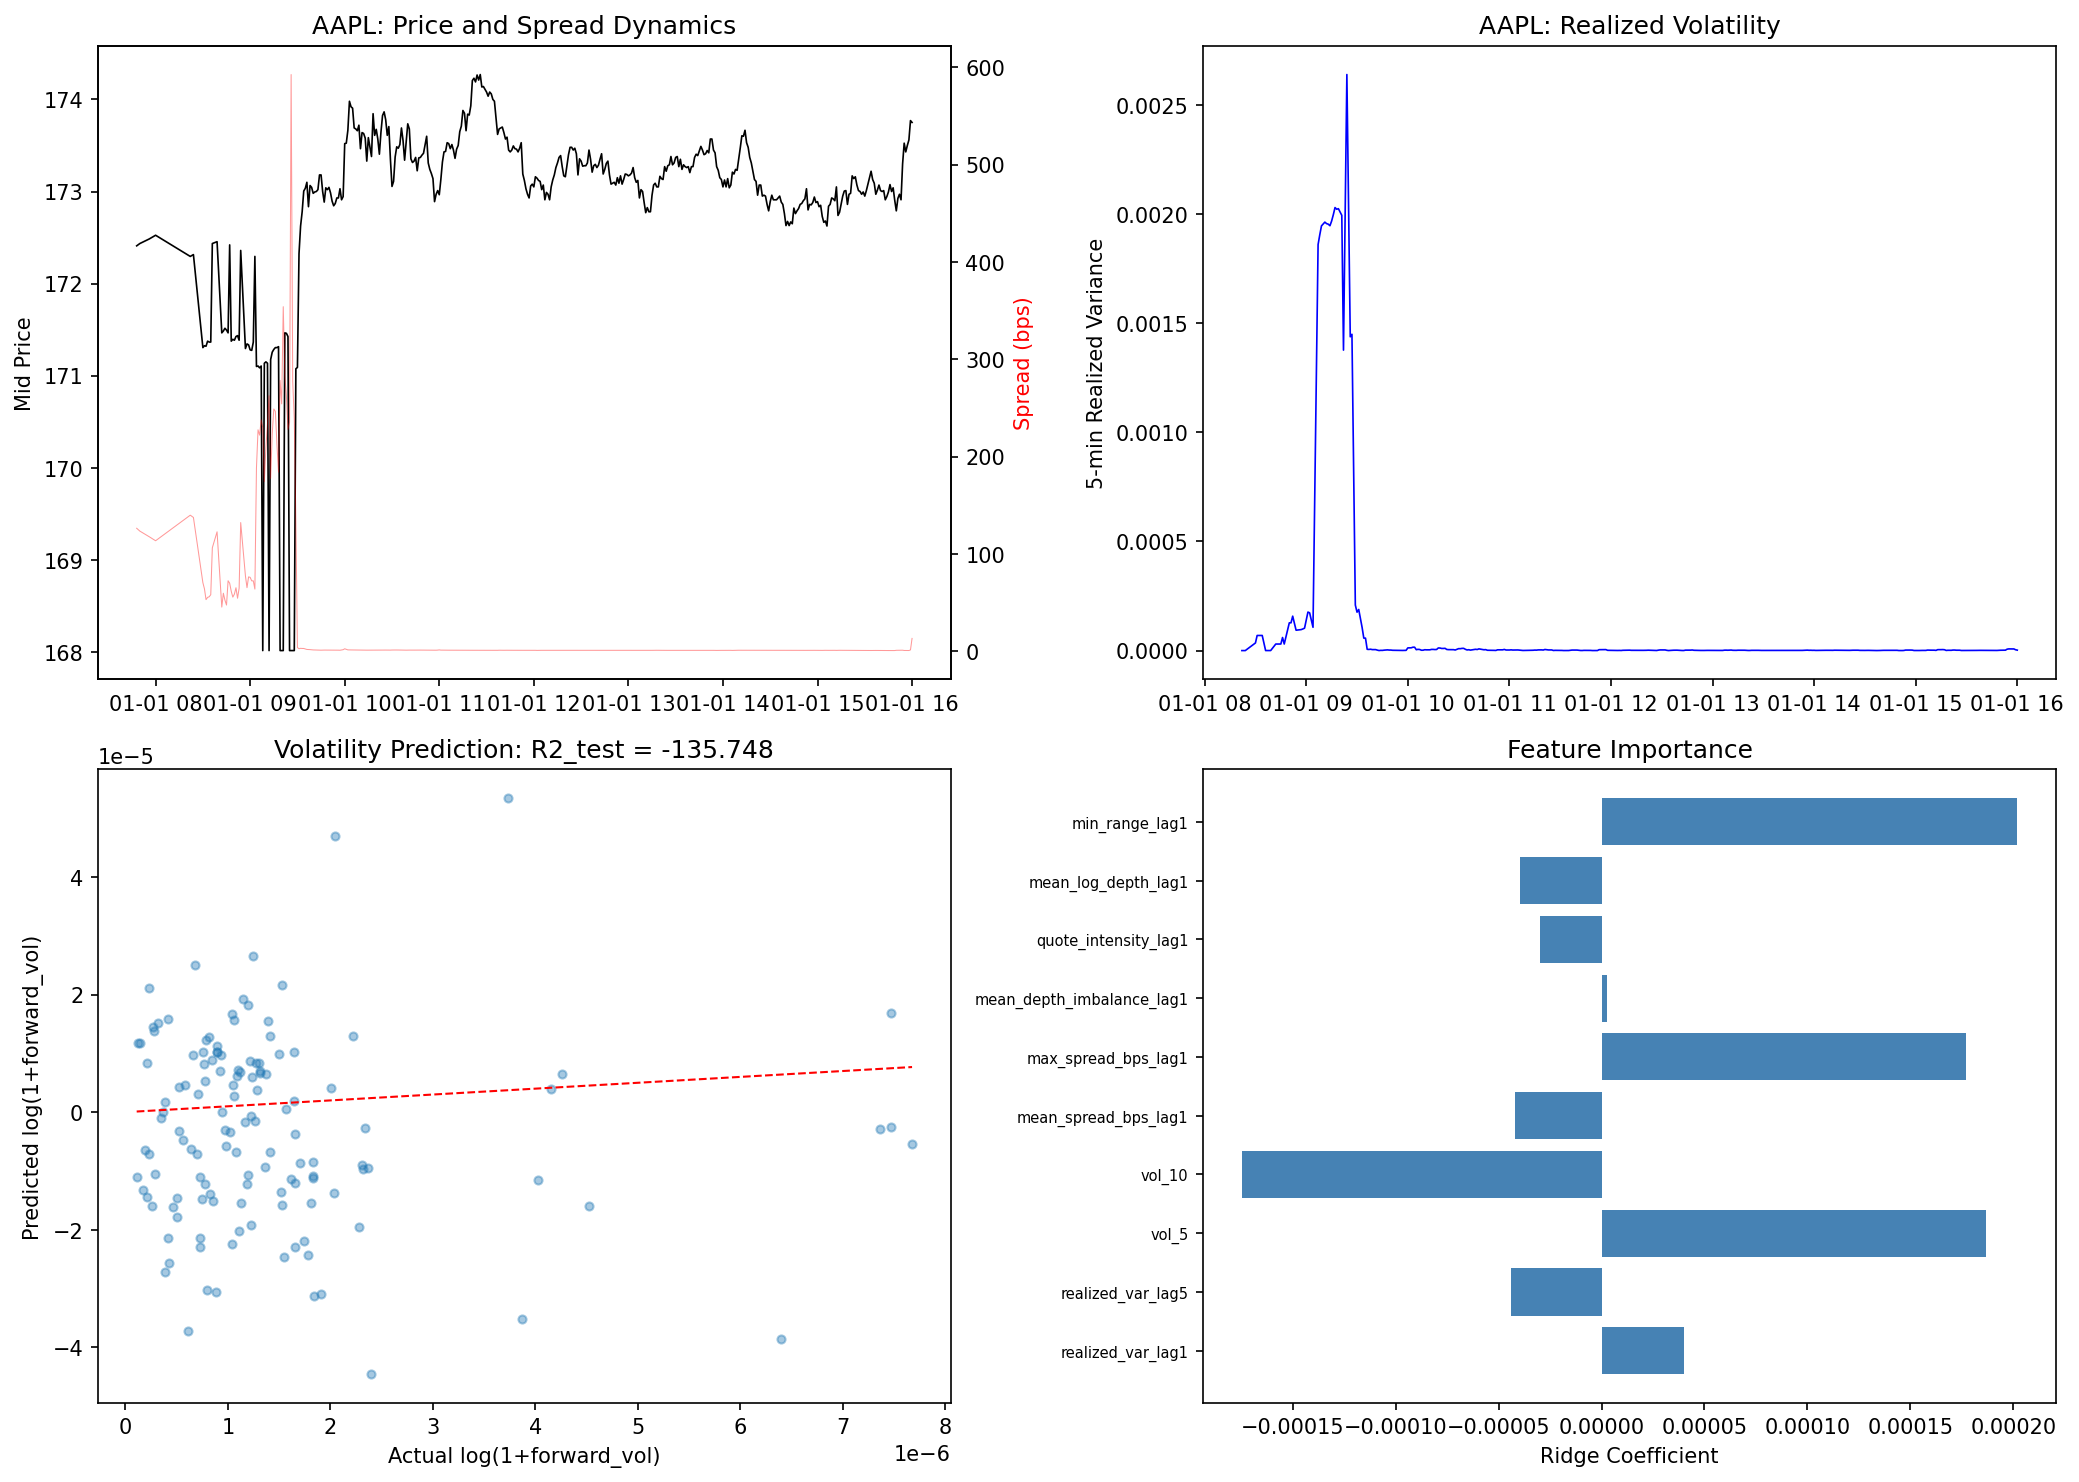


=== DIA — Advanced Features ===


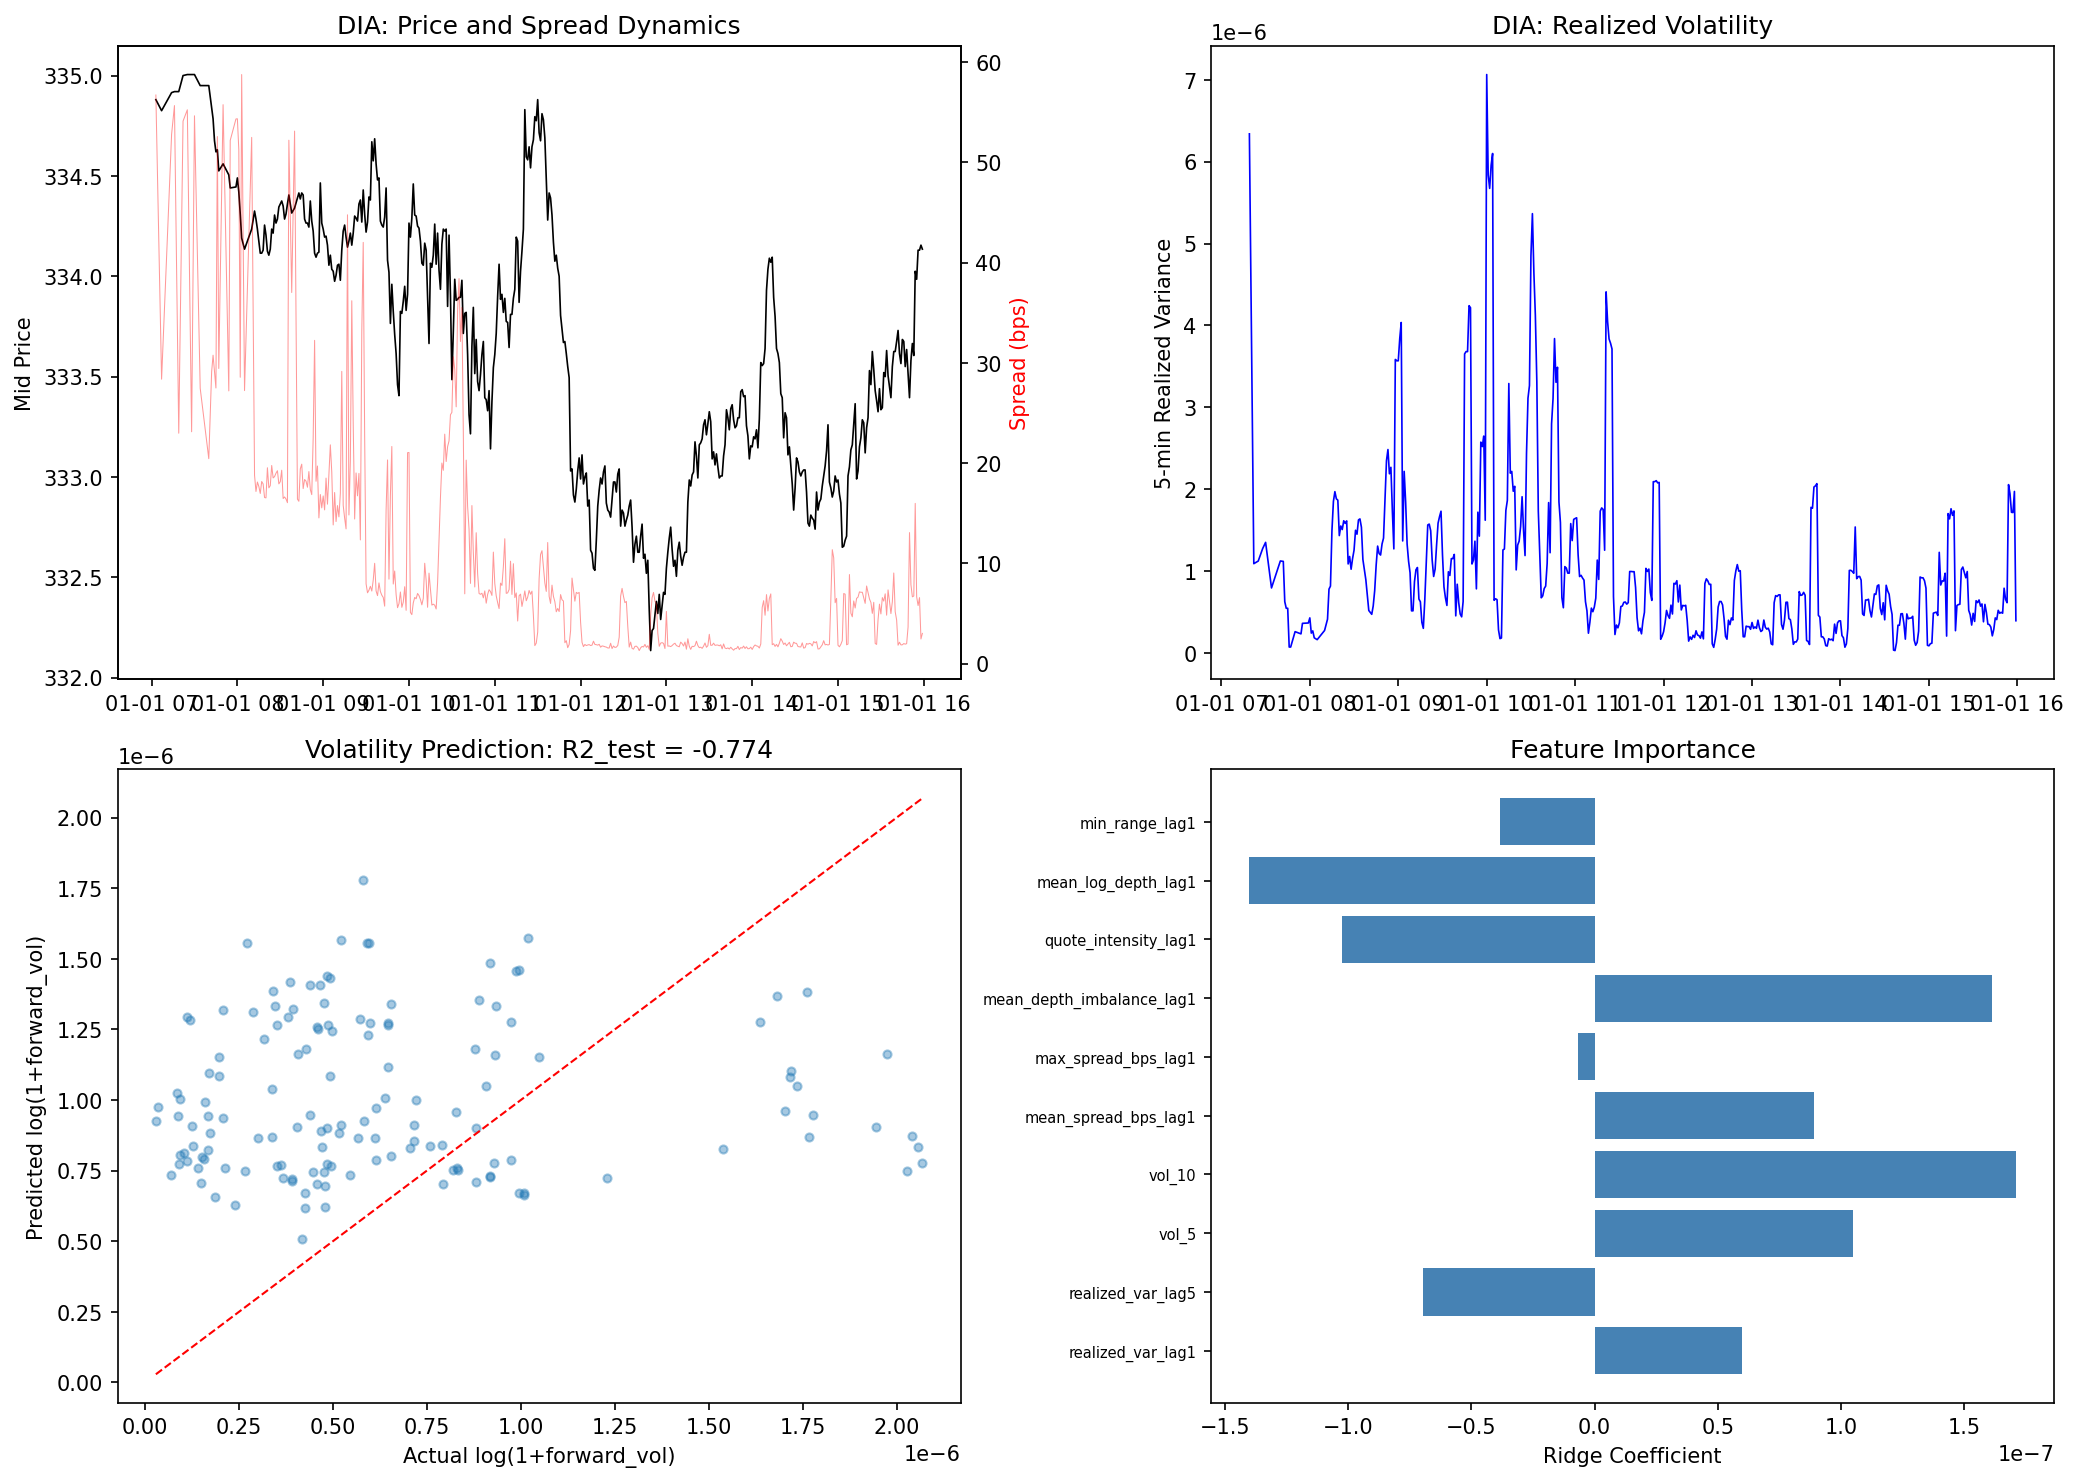


=== IVV — Advanced Features ===


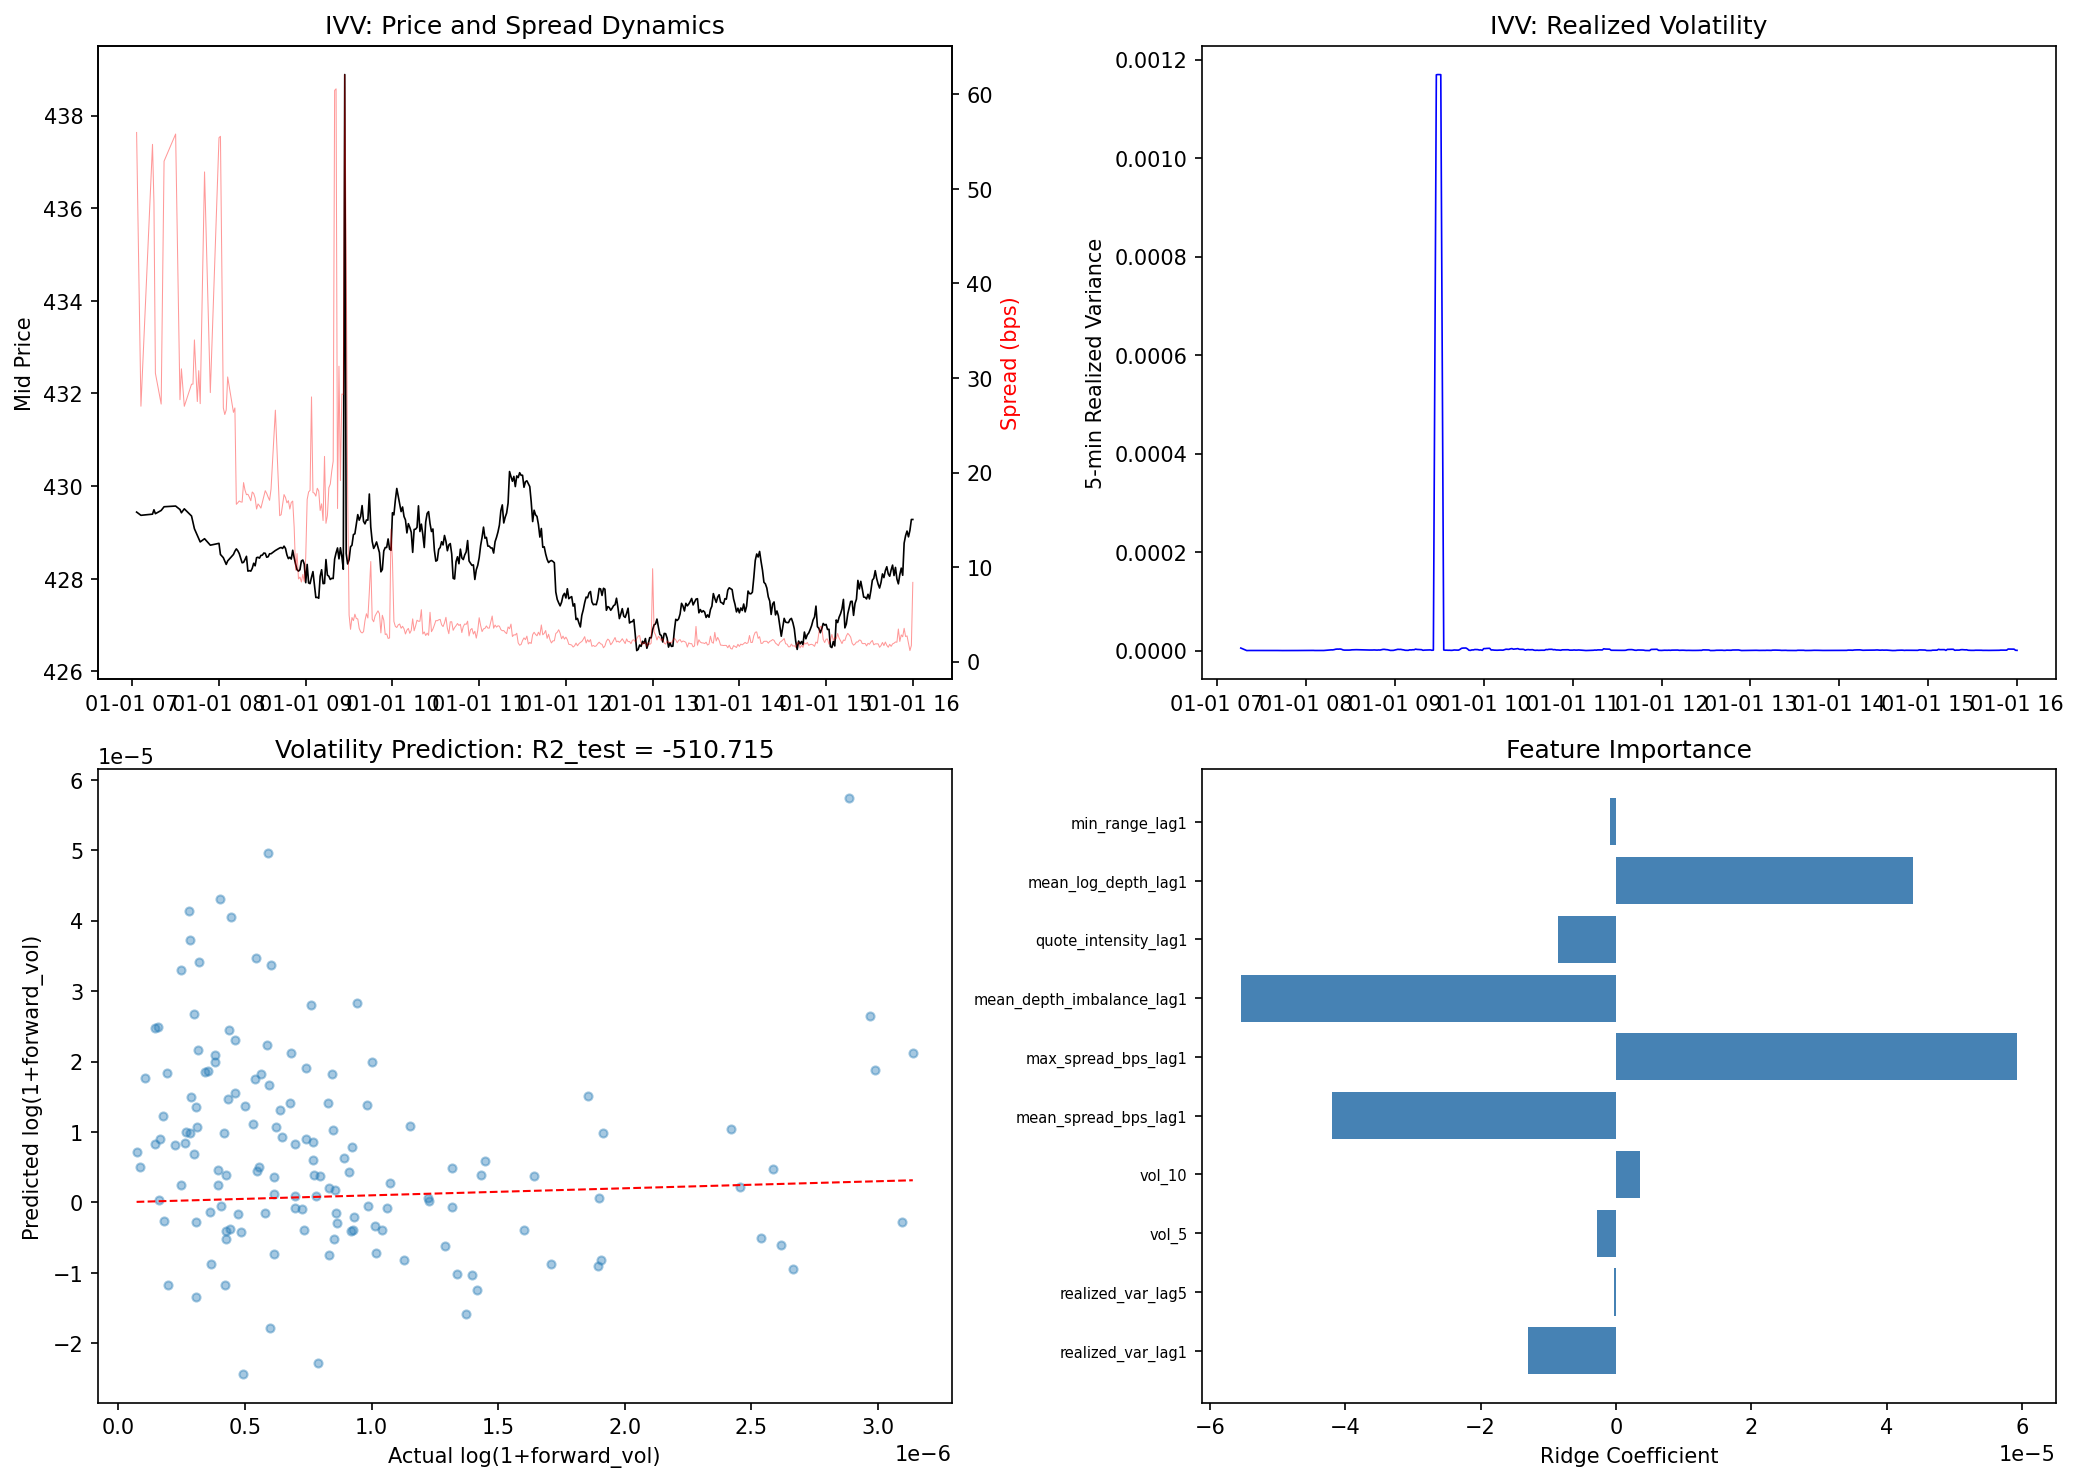


=== IWM — Advanced Features ===


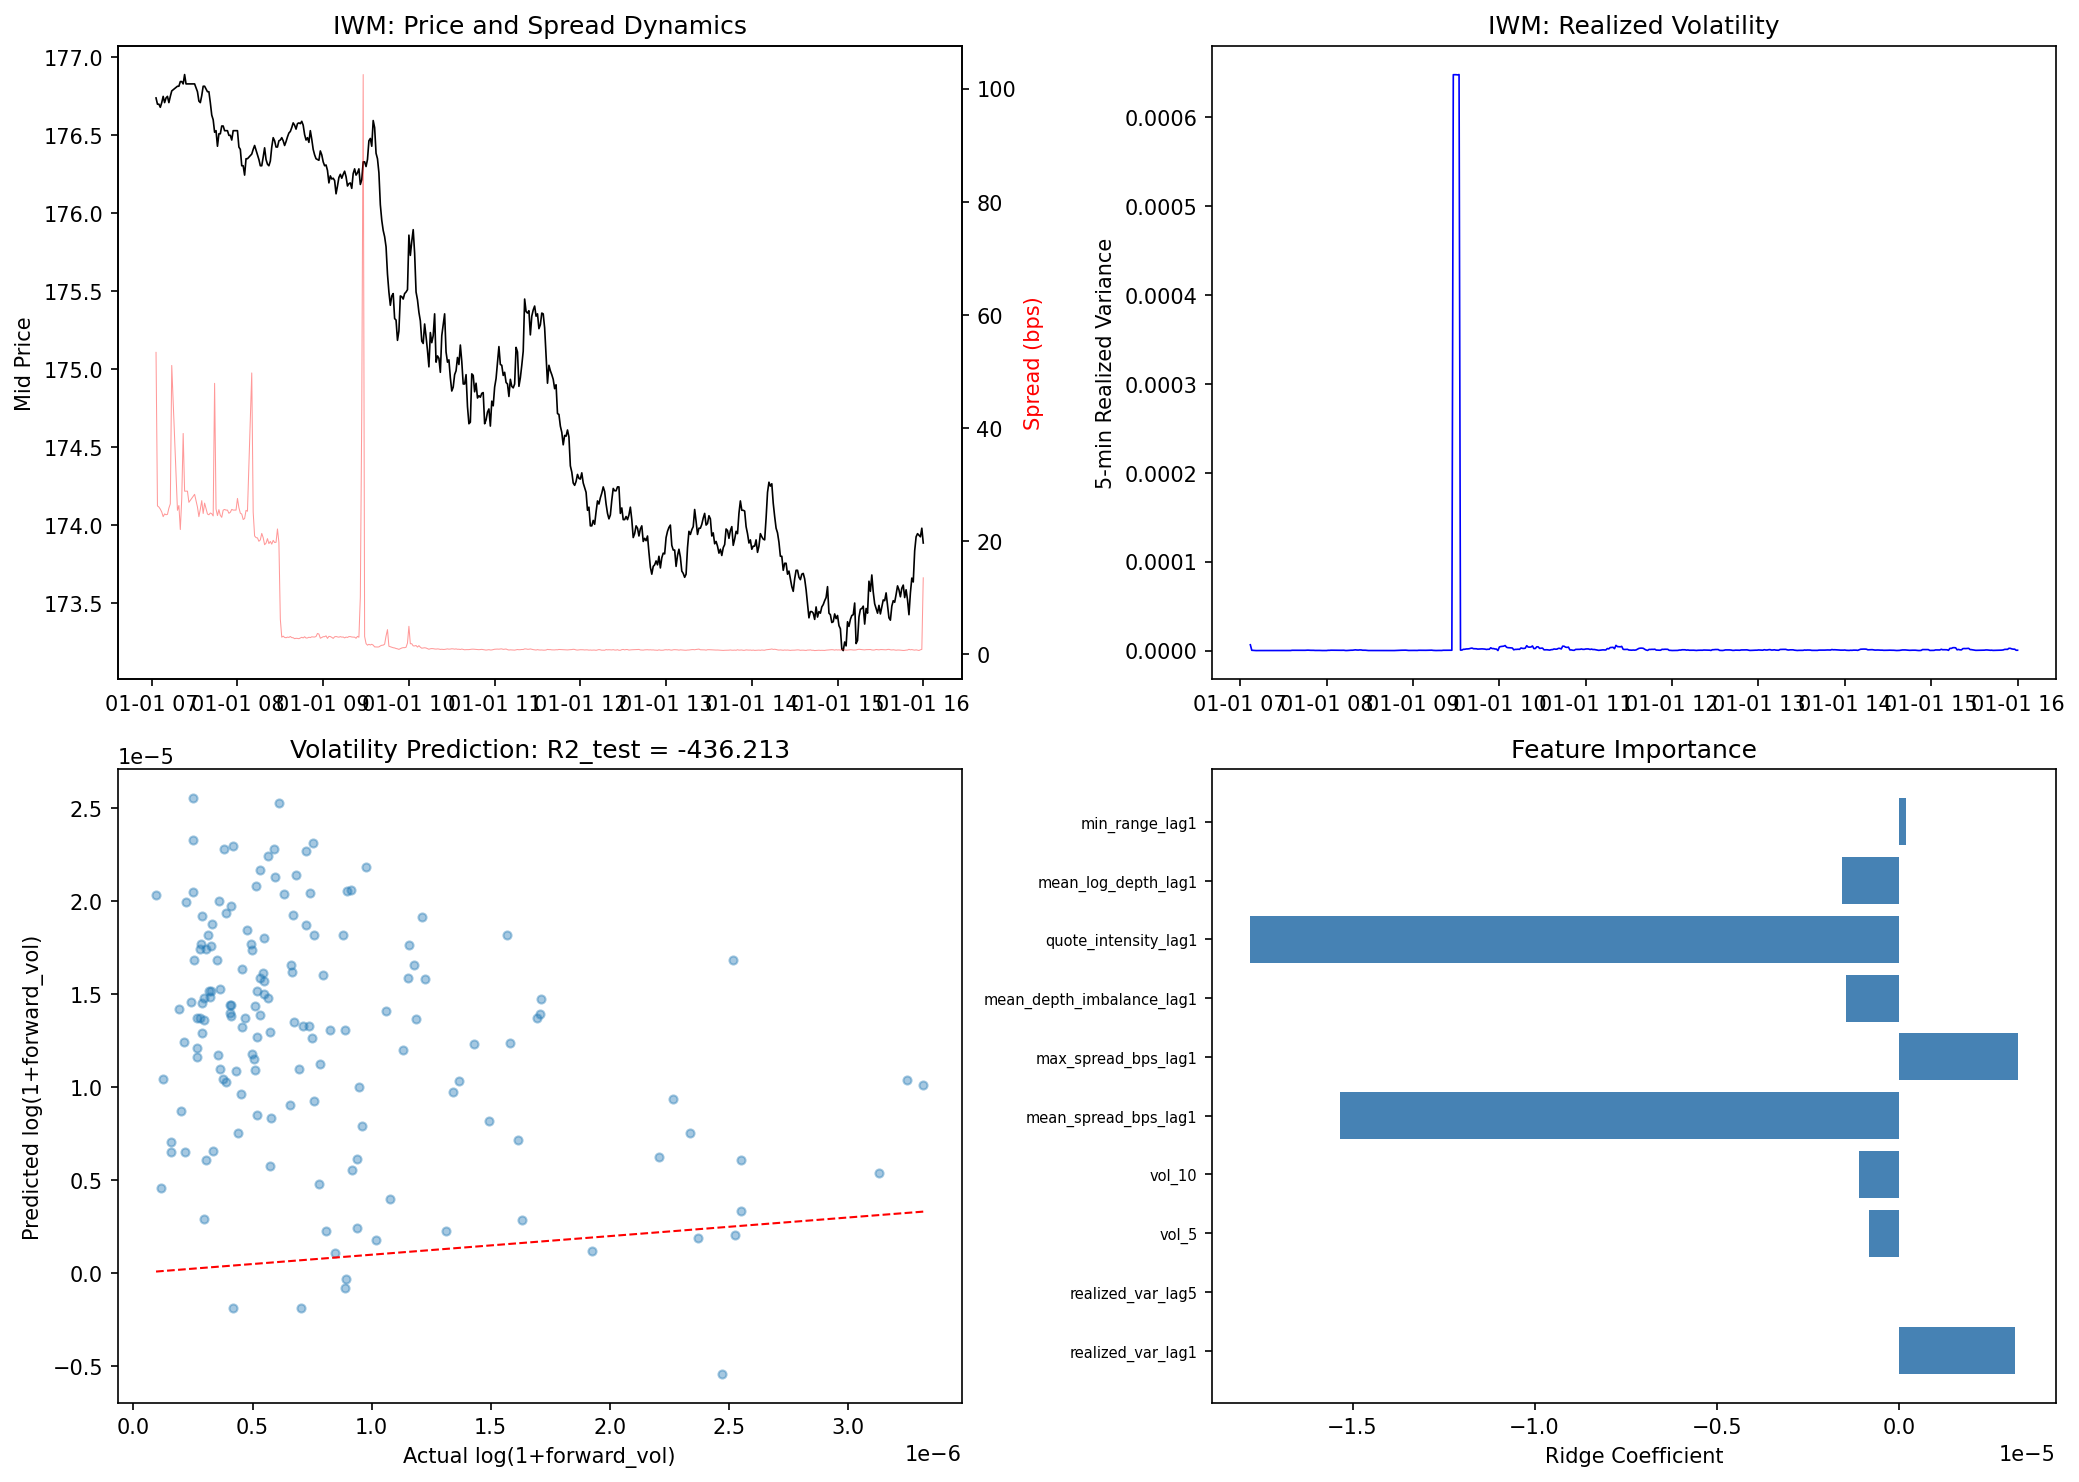


=== GOOGL — Advanced Features ===


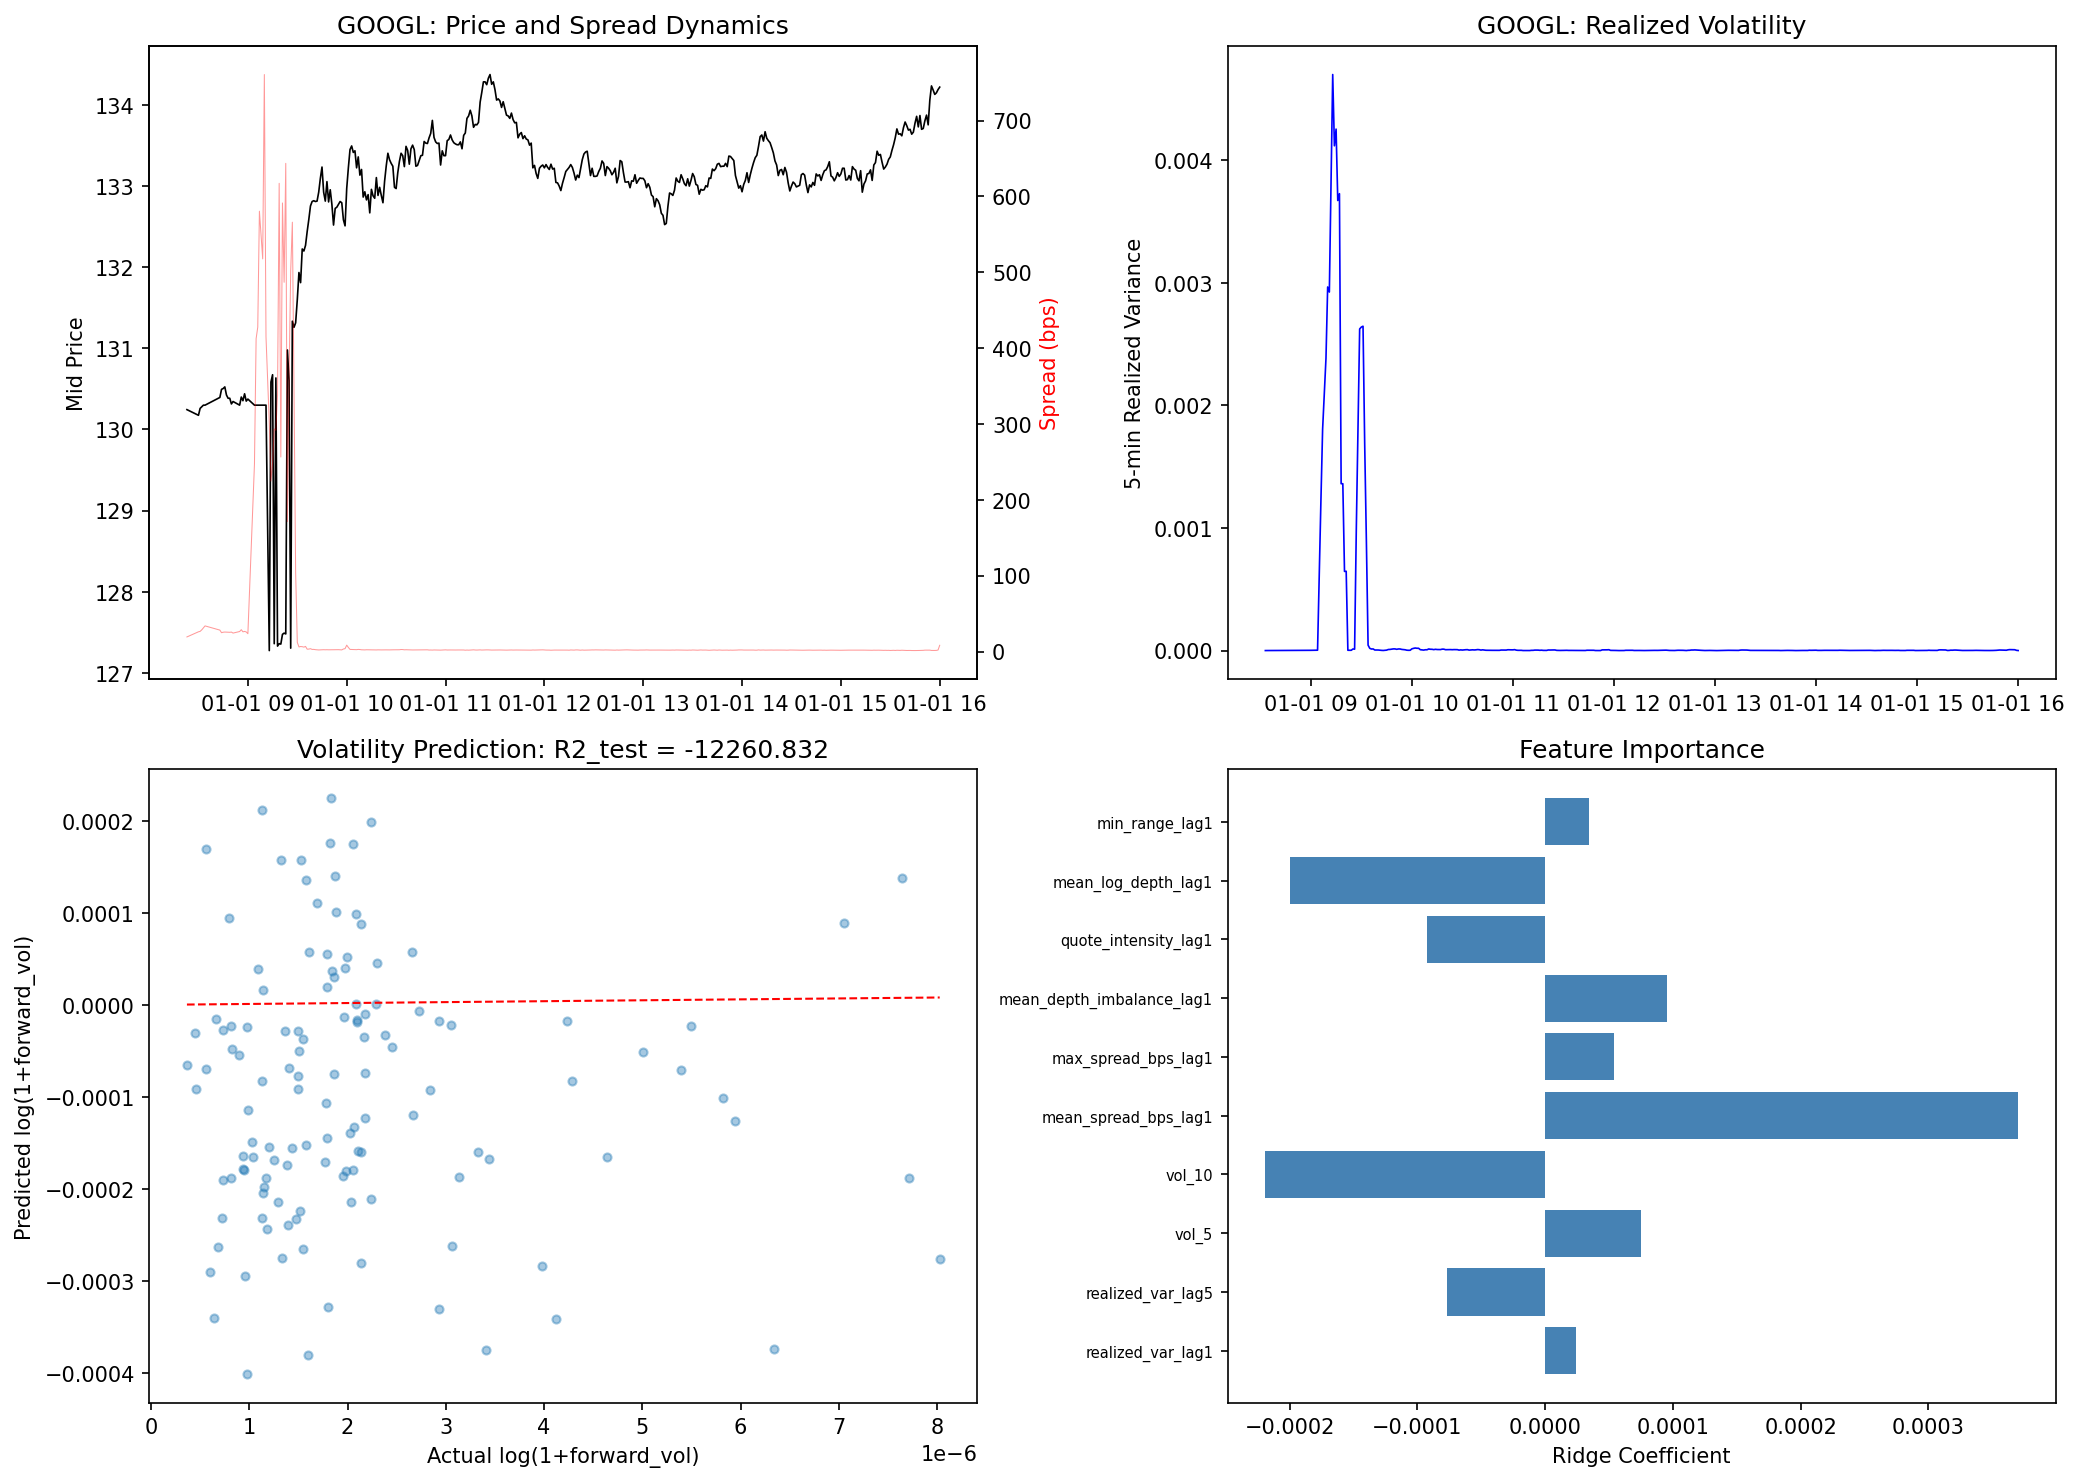


=== AMZN — Advanced Features ===


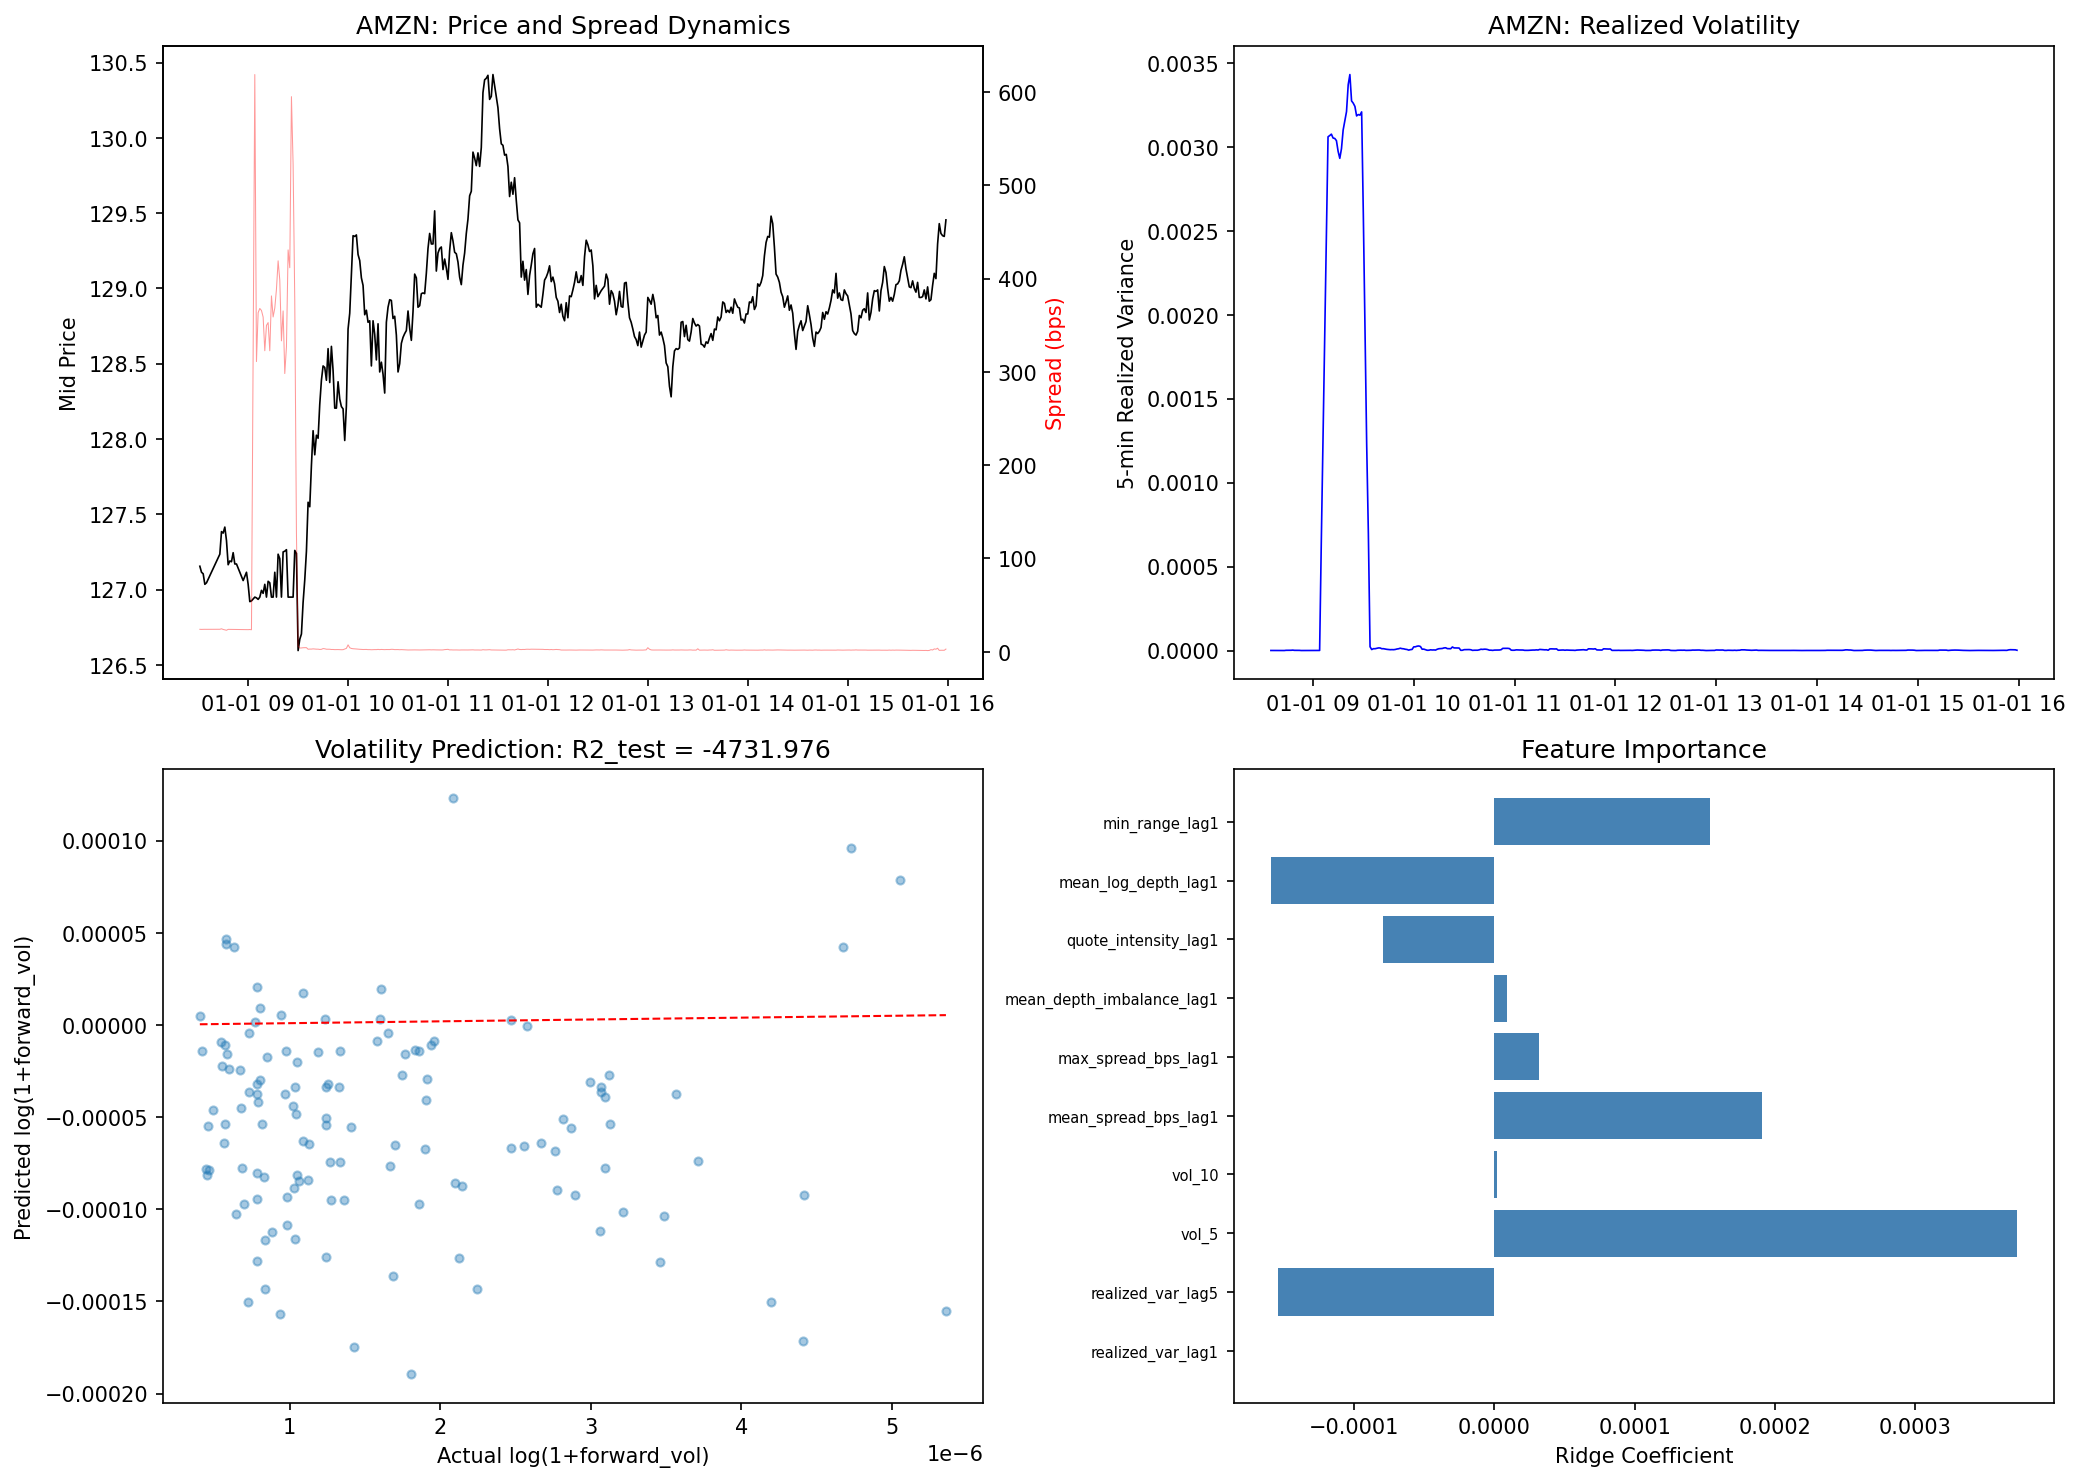

In [10]:
for symbol in ['AAPL', 'DIA', 'IVV', 'IWM', 'GOOGL', 'AMZN']:
    img_path = FOLDER / f'taq_advanced_{symbol}.png'
    if img_path.exists():
        print(f'\n=== {symbol} — Advanced Features ===')
        display(Image(filename=str(img_path)))

---
## Part 4: Predictive Analysis — 5-Second Bars (`taq_predictive_analysis.py`)

This script uses **5-second bars** (instead of 1-minute) for higher resolution. It builds the same microstructure features but at a finer timescale, then tests whether they predict:
- **1-bar forward return** (5 seconds ahead)
- **5-bar forward return** (25 seconds ahead)

### Additional features:
- `spread_x_imbalance` — interaction between spread and depth imbalance
- `return_vol_10`, `return_mean_10` — rolling moments of returns

In [11]:
predictive = pd.read_csv(FOLDER / 'taq_predictive_summary.csv')
print('=== 5-Second Bar Predictive Results ===')
print(predictive[['symbol', 'horizon', 'r2_train', 'r2_test', 'directional_accuracy', 'n_test']].to_string(index=False))
print()
print('Interpretation:')
print('  - R² train is small but positive (0.001 to 0.12) — weak signal exists')
print('  - R² test is mostly negative — overfitting with limited data')
print('  - Directional accuracy is near 50% — basically a coin flip')
print('  - IWM 5-bar: 52.5% directional accuracy is the best result')
print('  - With only 1 hour of data, this is expected. More data should improve this.')

=== 5-Second Bar Predictive Results ===
symbol horizon  r2_train    r2_test  directional_accuracy  n_test
  AAPL    1bar  0.122221 -13.975348              0.416118     608
  AAPL    5bar  0.022887  -0.227738              0.502471     607
   DIA    1bar  0.001092  -0.007994              0.389626    1658
   DIA    5bar  0.000323  -0.011635              0.462281    1657
   IVV    1bar  0.001601  -0.010122              0.477711    1660
   IVV    5bar  0.012806  -0.035718              0.503315    1659
   IWM    1bar  0.001742  -0.023039              0.428322    1144
   IWM    5bar  0.003527   0.000913              0.524934    1143
 GOOGL    1bar  0.030526  -0.679715              0.440136    1470
 GOOGL    5bar  0.072680   0.004542              0.490129    1469
  AMZN    1bar  0.024837  -0.126216              0.462517    1494
  AMZN    5bar  0.012328   0.002979              0.470864    1493

Interpretation:
  - R² train is small but positive (0.001 to 0.12) — weak signal exists
  - R² test i

### Per-symbol predictive plots

Each plot has 4 panels:
1. **Top-left:** Mid price (black) and spread (red) over 5-second bars
2. **Top-right:** Depth imbalance over time — positive = bid heavy, negative = ask heavy
3. **Bottom-left:** Feature importance (Ridge coefficients) — which features predict returns
4. **Bottom-right:** Predicted vs actual forward return (scatter) — visual fit quality


=== AAPL — 5-Second Bar Predictive Analysis ===


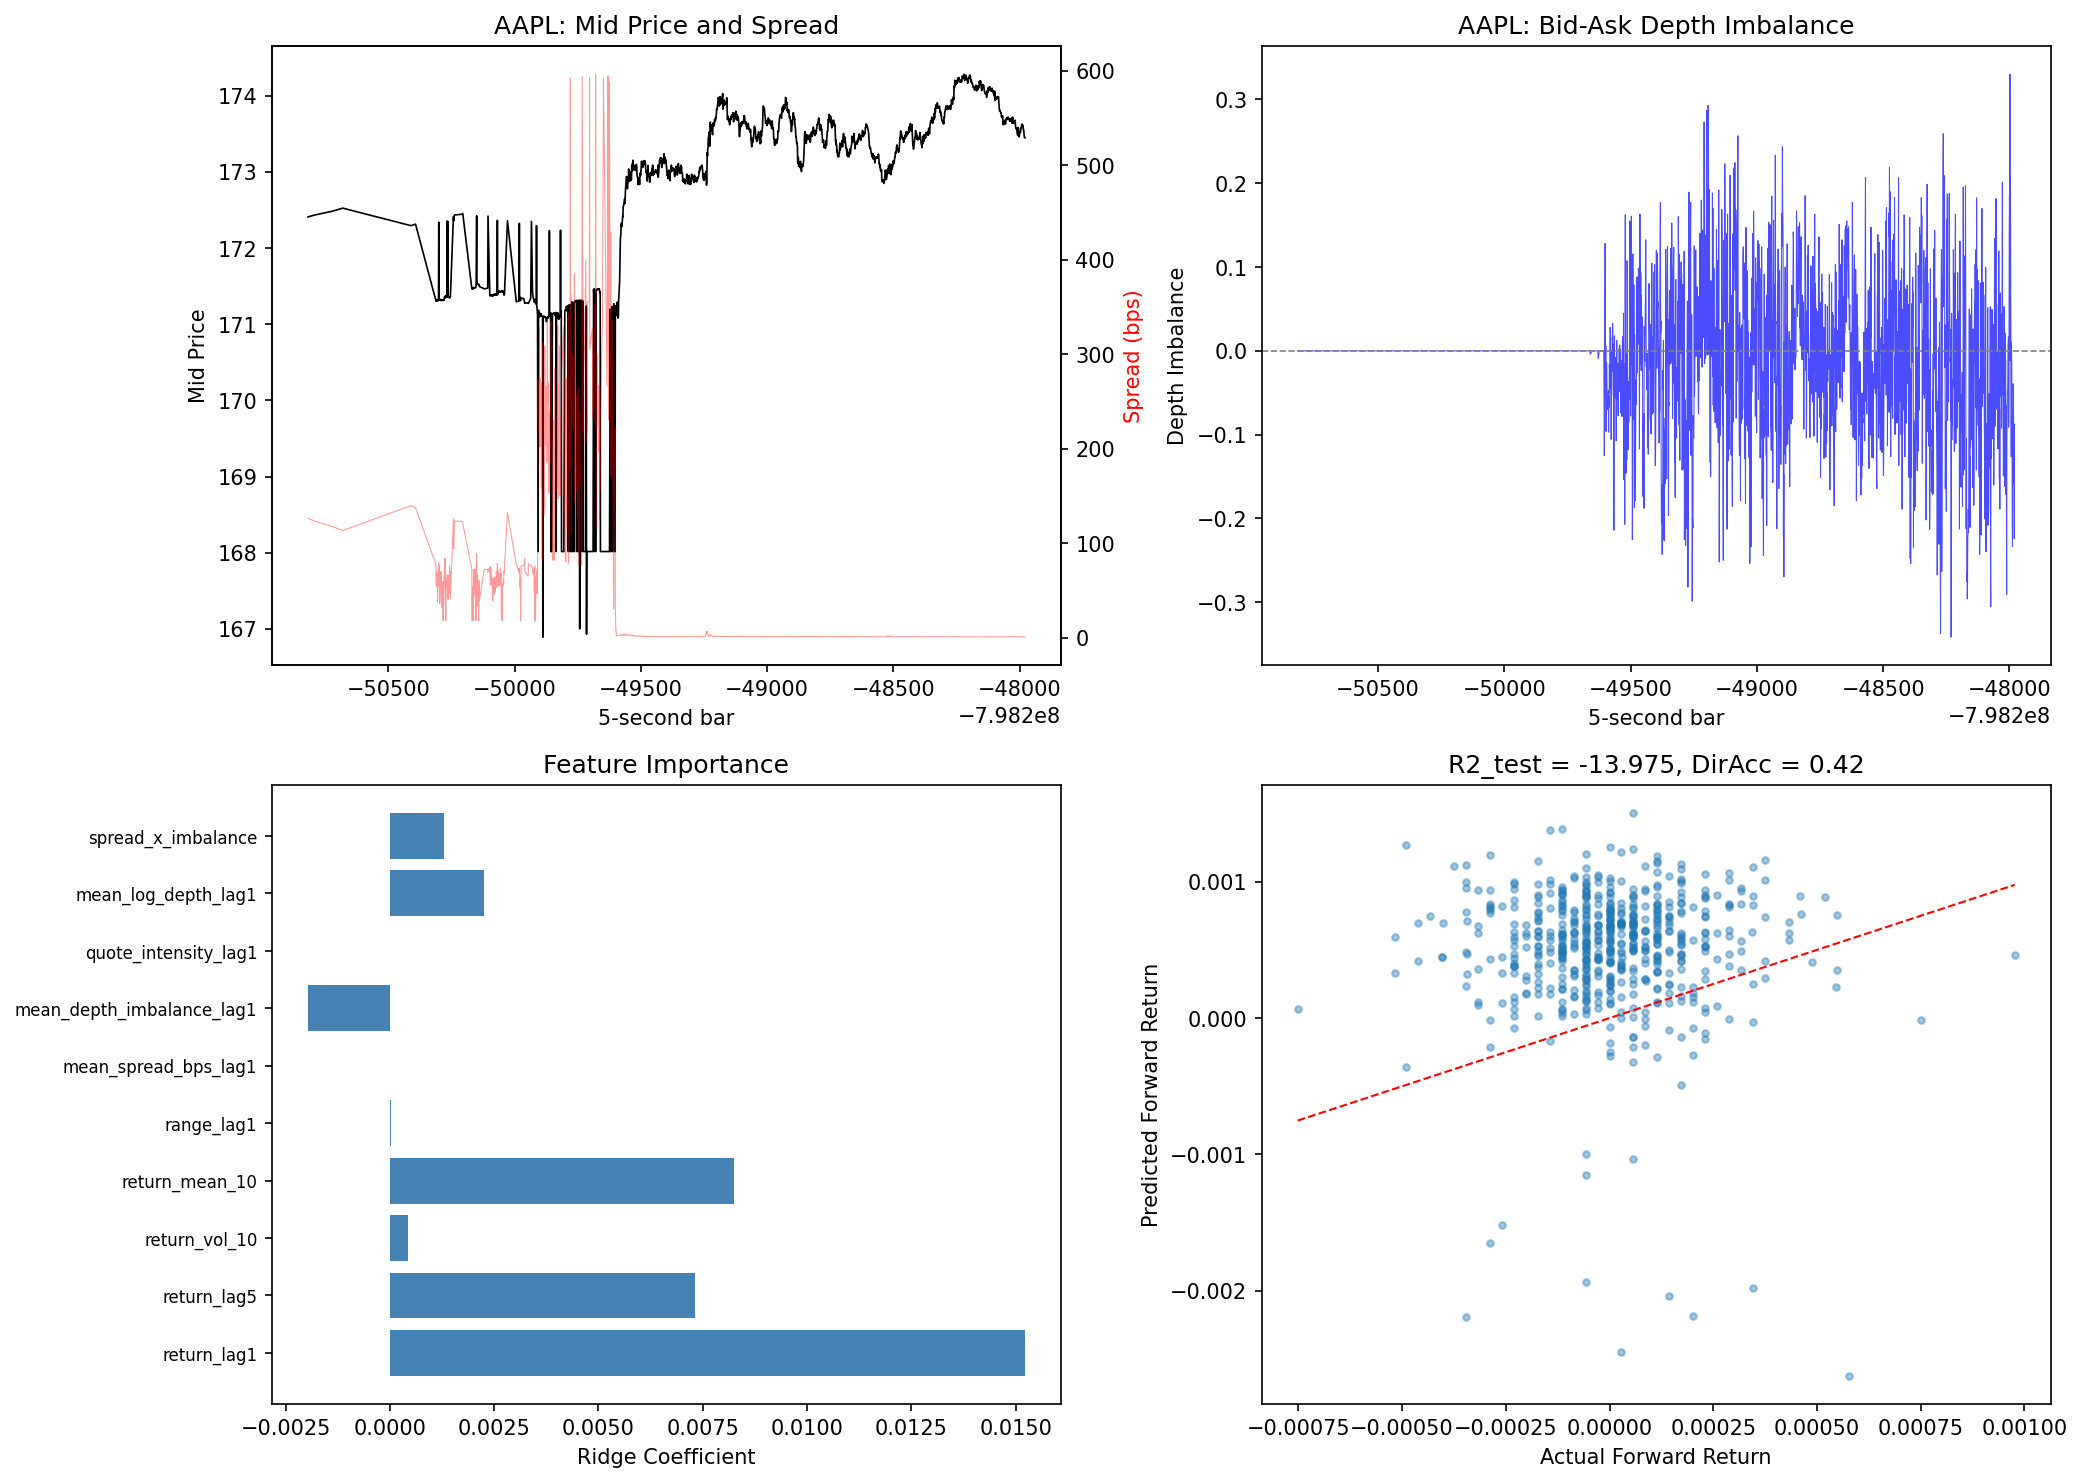


=== DIA — 5-Second Bar Predictive Analysis ===


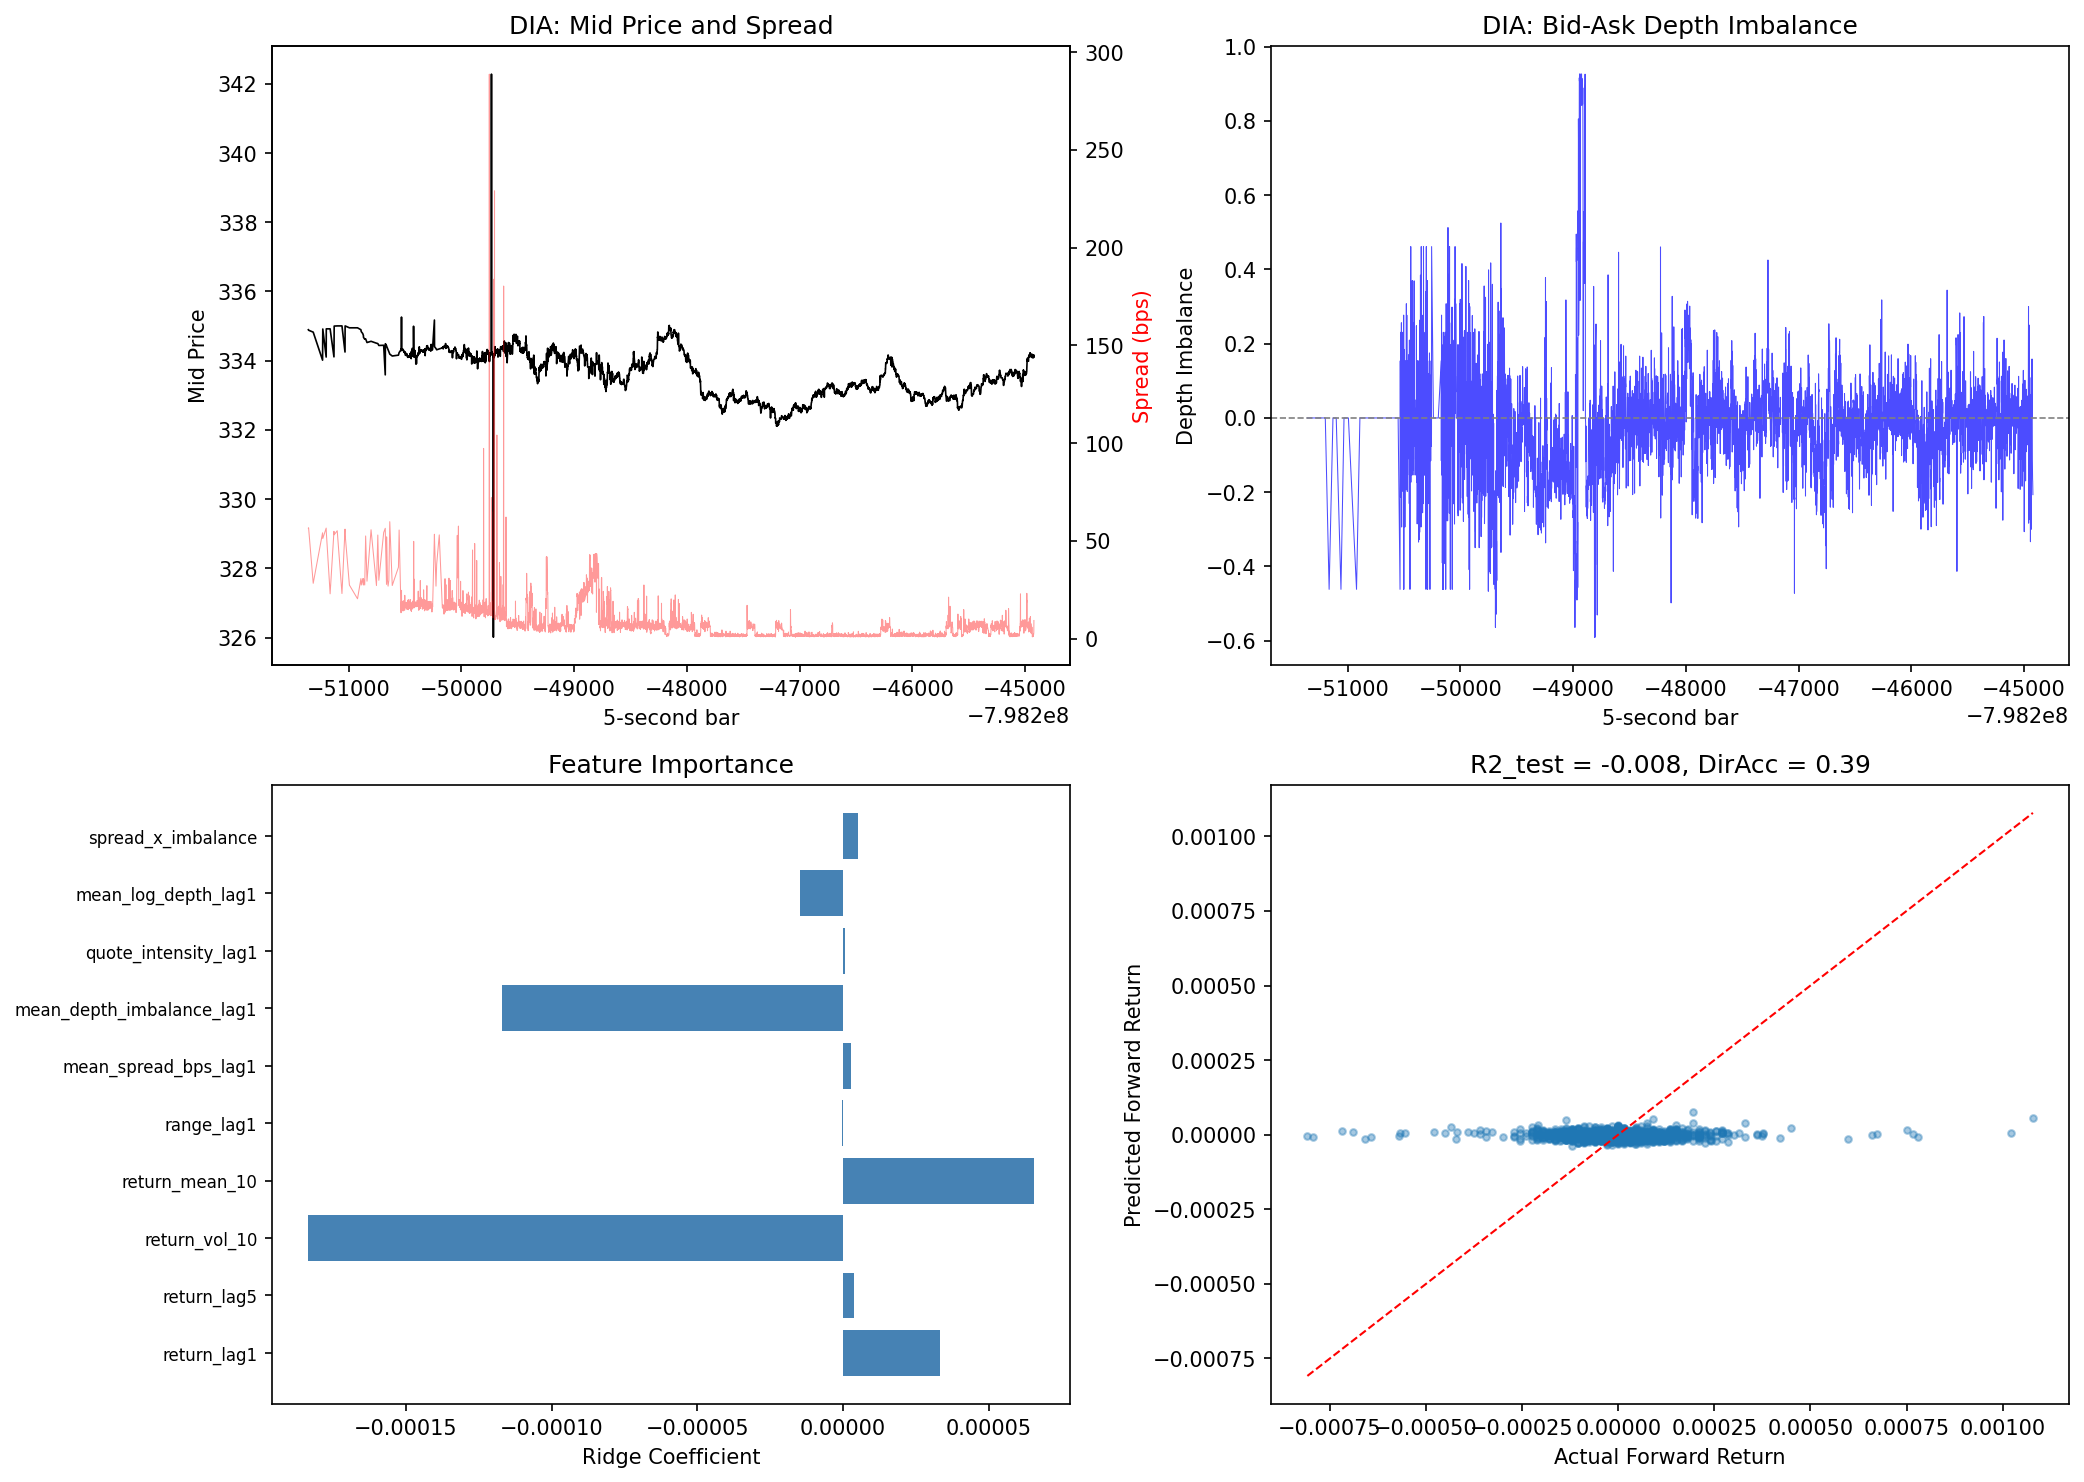


=== IVV — 5-Second Bar Predictive Analysis ===


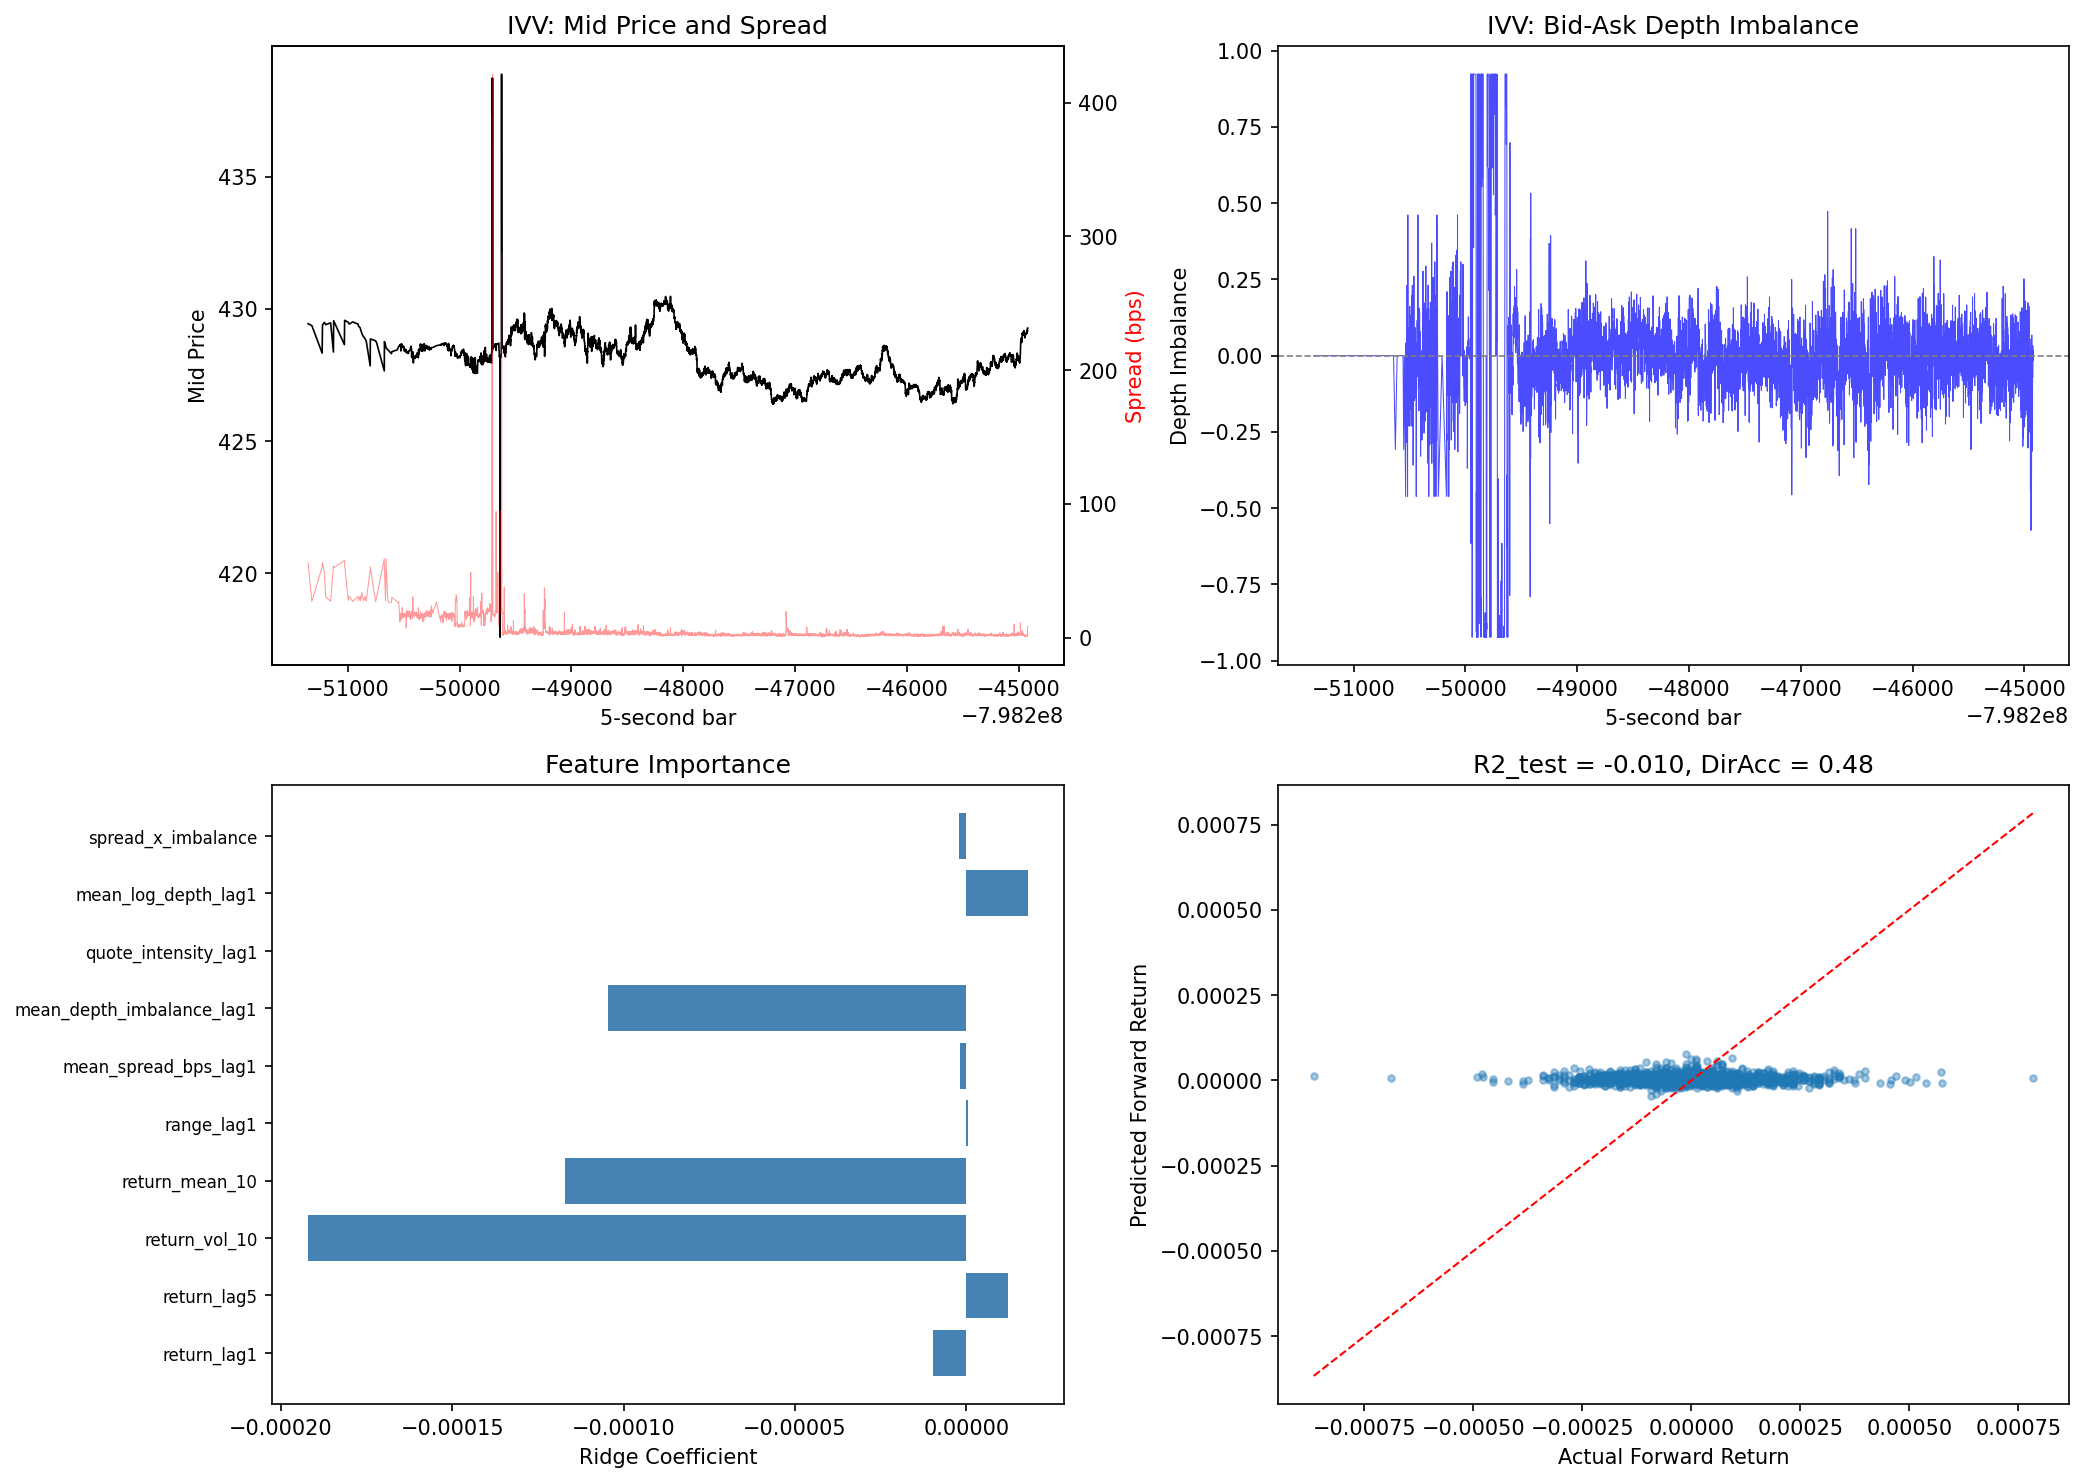


=== IWM — 5-Second Bar Predictive Analysis ===


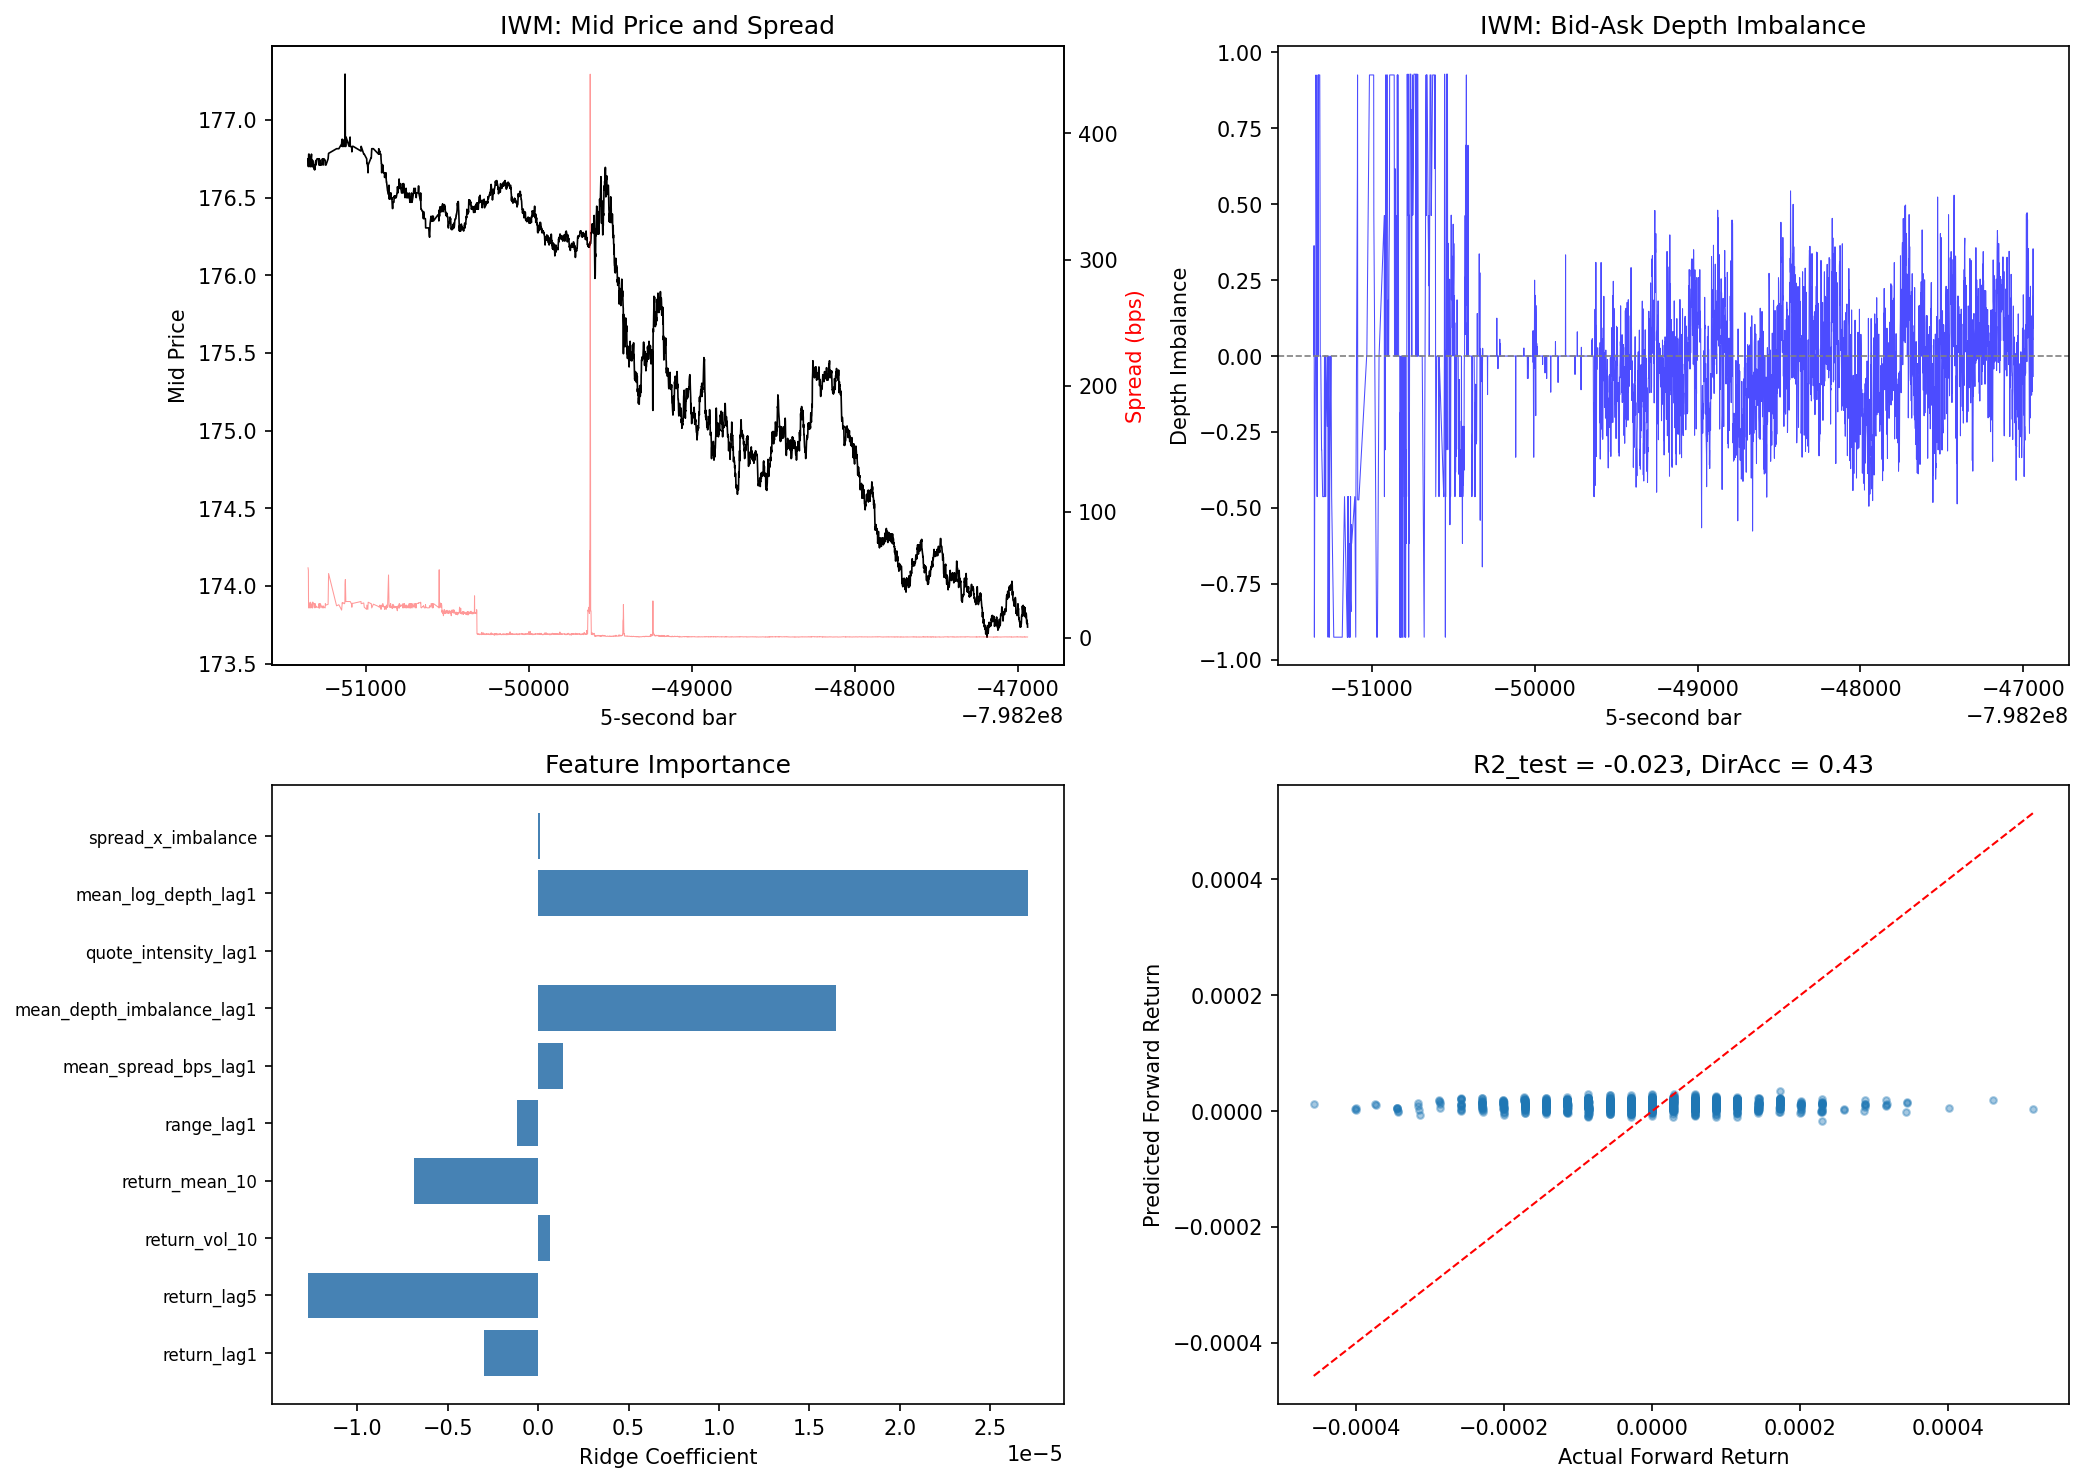


=== GOOGL — 5-Second Bar Predictive Analysis ===


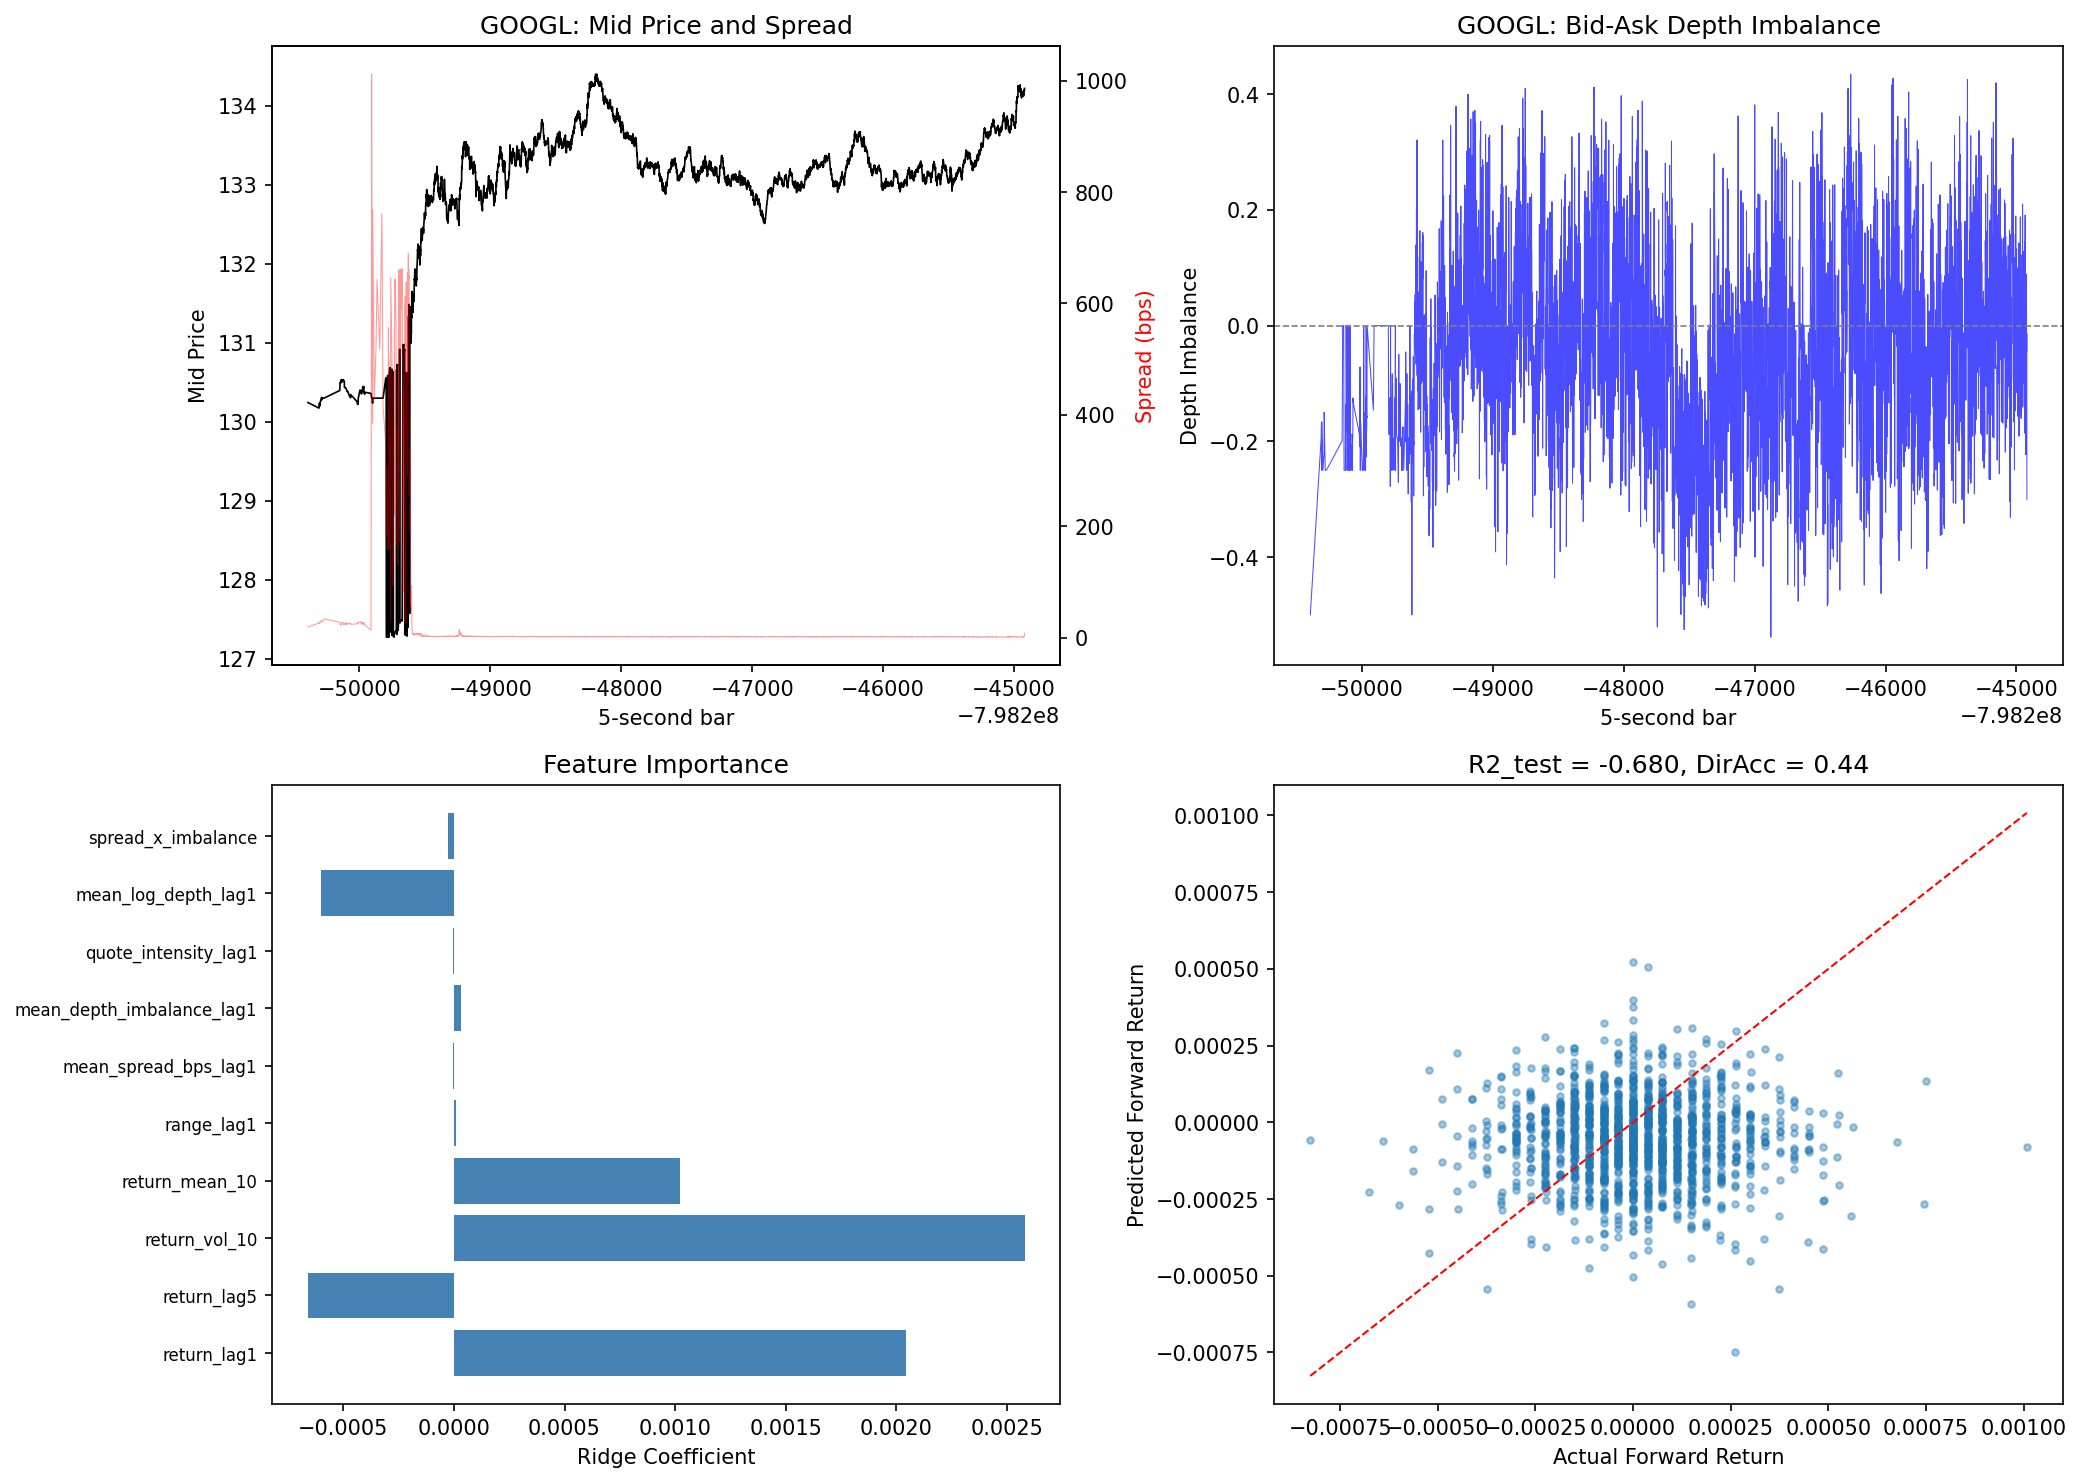


=== AMZN — 5-Second Bar Predictive Analysis ===


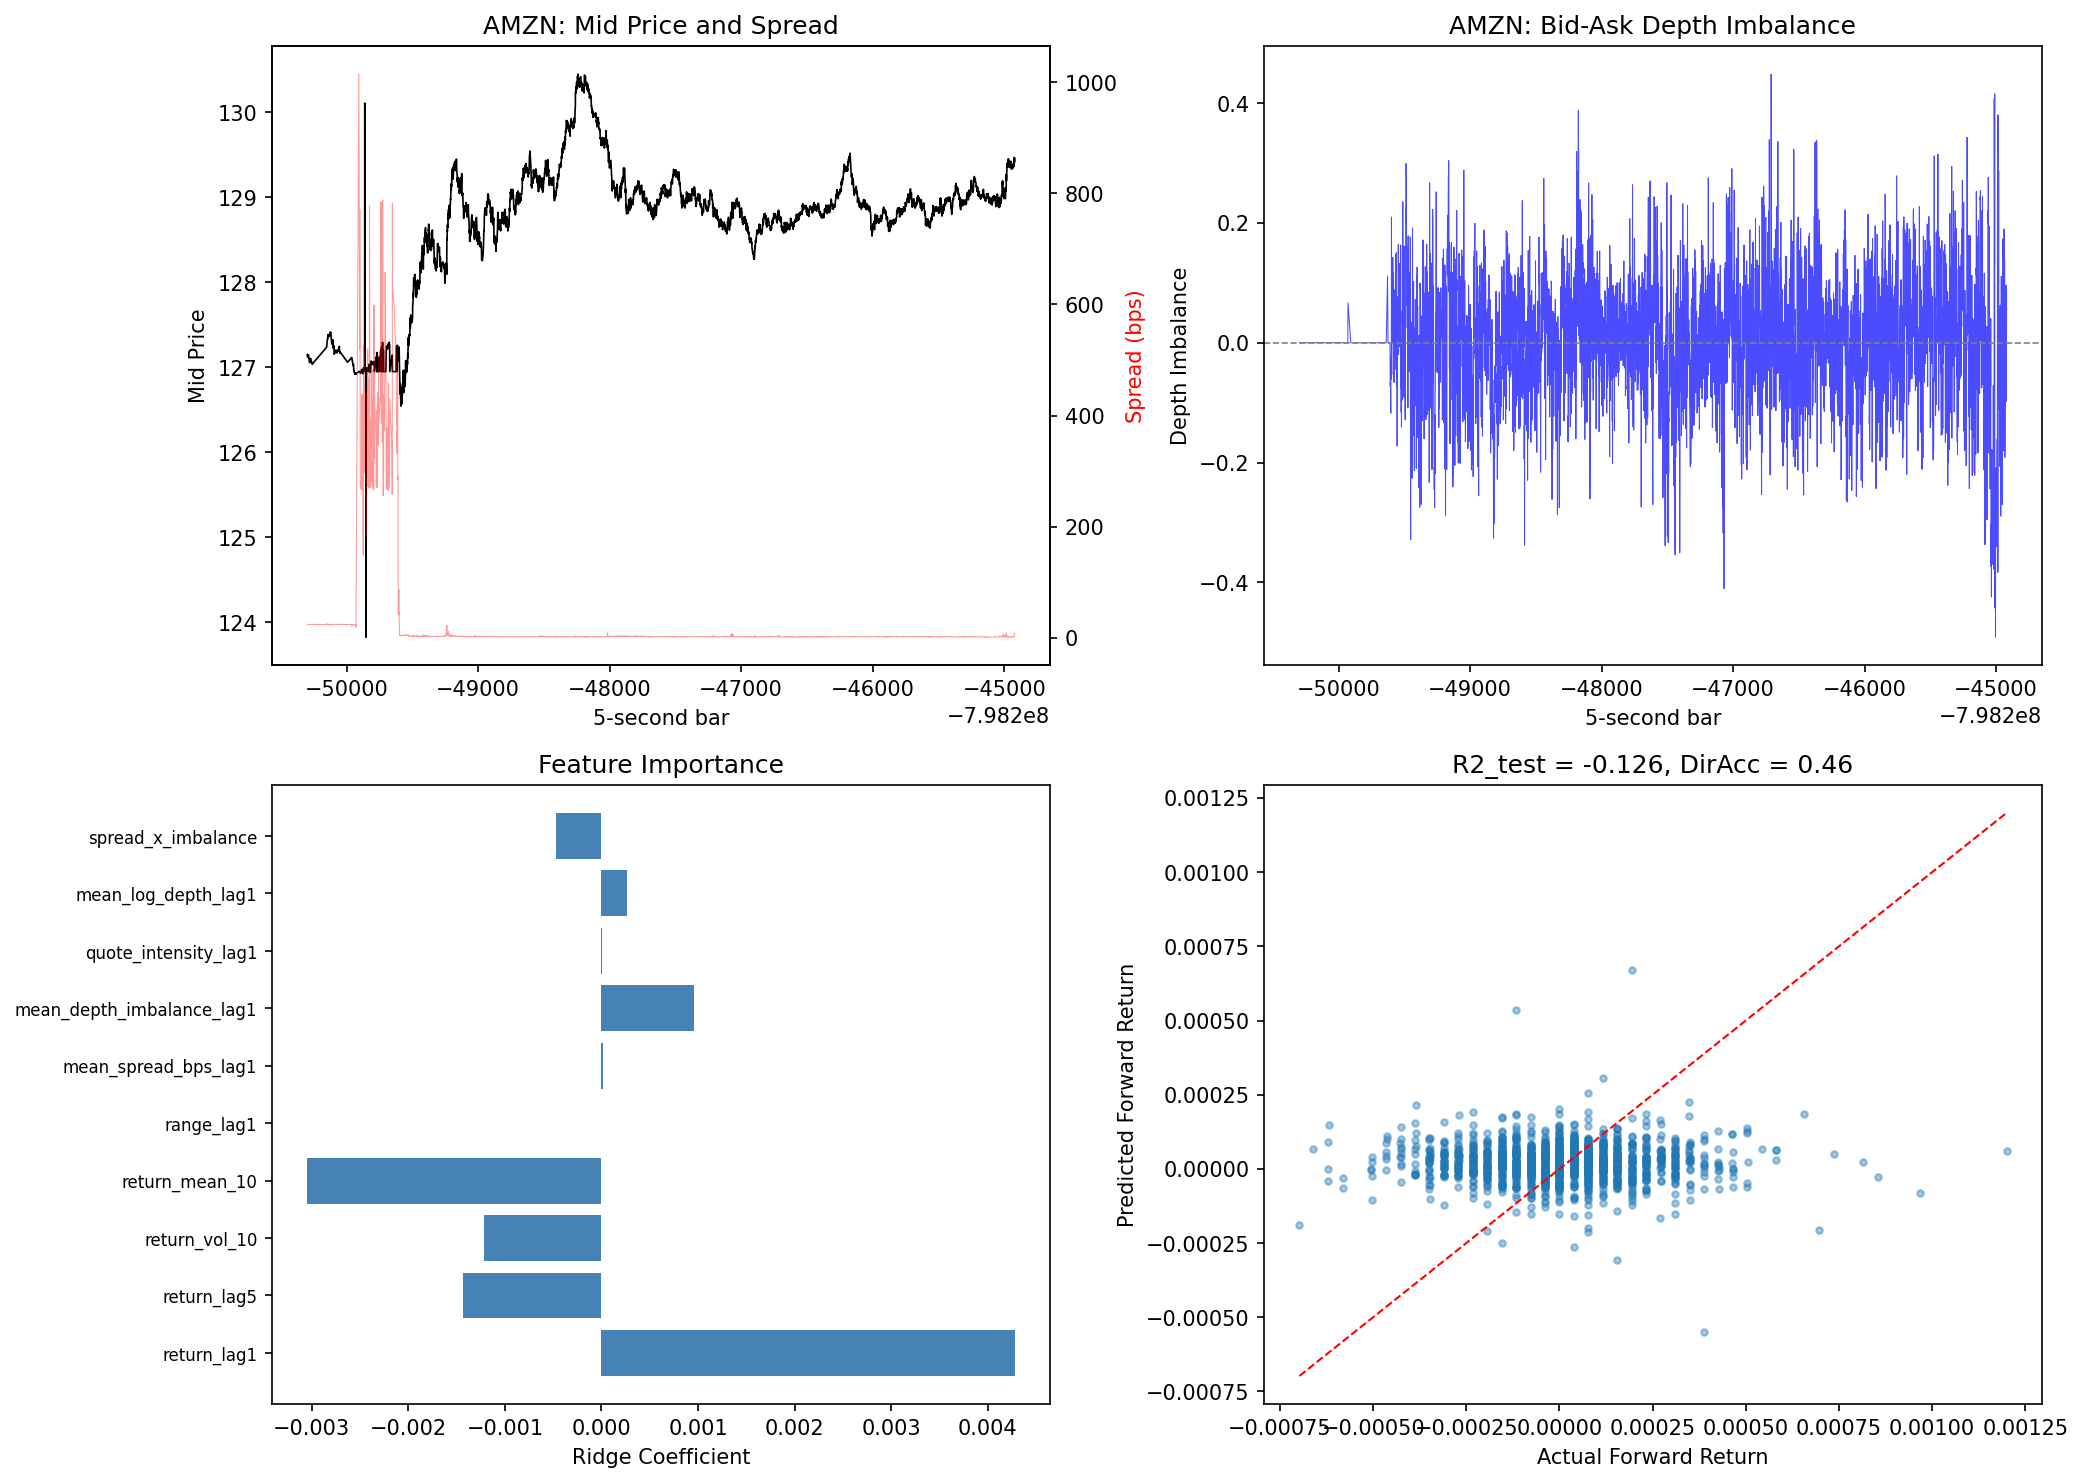

In [12]:
for symbol in ['AAPL', 'DIA', 'IVV', 'IWM', 'GOOGL', 'AMZN']:
    img_path = FOLDER / f'taq_predictive_{symbol}.png'
    if img_path.exists():
        print(f'\n=== {symbol} — 5-Second Bar Predictive Analysis ===')
        display(Image(filename=str(img_path)))

---
## Part 5: Microstructure Signal — Depth Imbalance (`taq_microstructure_signal.py`)

This script tests the **classic microstructure hypothesis**: that order flow imbalance (measured by depth imbalance at the best bid/ask) predicts short-term price direction.

### Method:
- Parse BBO quotes for each symbol
- Compute depth imbalance = (bid_sz - ask_sz) / (bid_sz + ask_sz)
- Bin quotes into time intervals
- Use logistic regression to predict: does positive depth imbalance predict positive next-period return?

### Per-symbol signal plots

Each plot shows:
1. **Top-left:** Mid price and depth imbalance over time
2. **Top-right:** Depth imbalance vs forward return (scatter) — is there a relationship?
3. **Bottom-left:** Cumulative PnL from trading the signal — does it make money?
4. **Bottom-right:** Signal accuracy by imbalance bucket — does extreme imbalance predict better?


=== AAPL — Depth Imbalance Signal ===


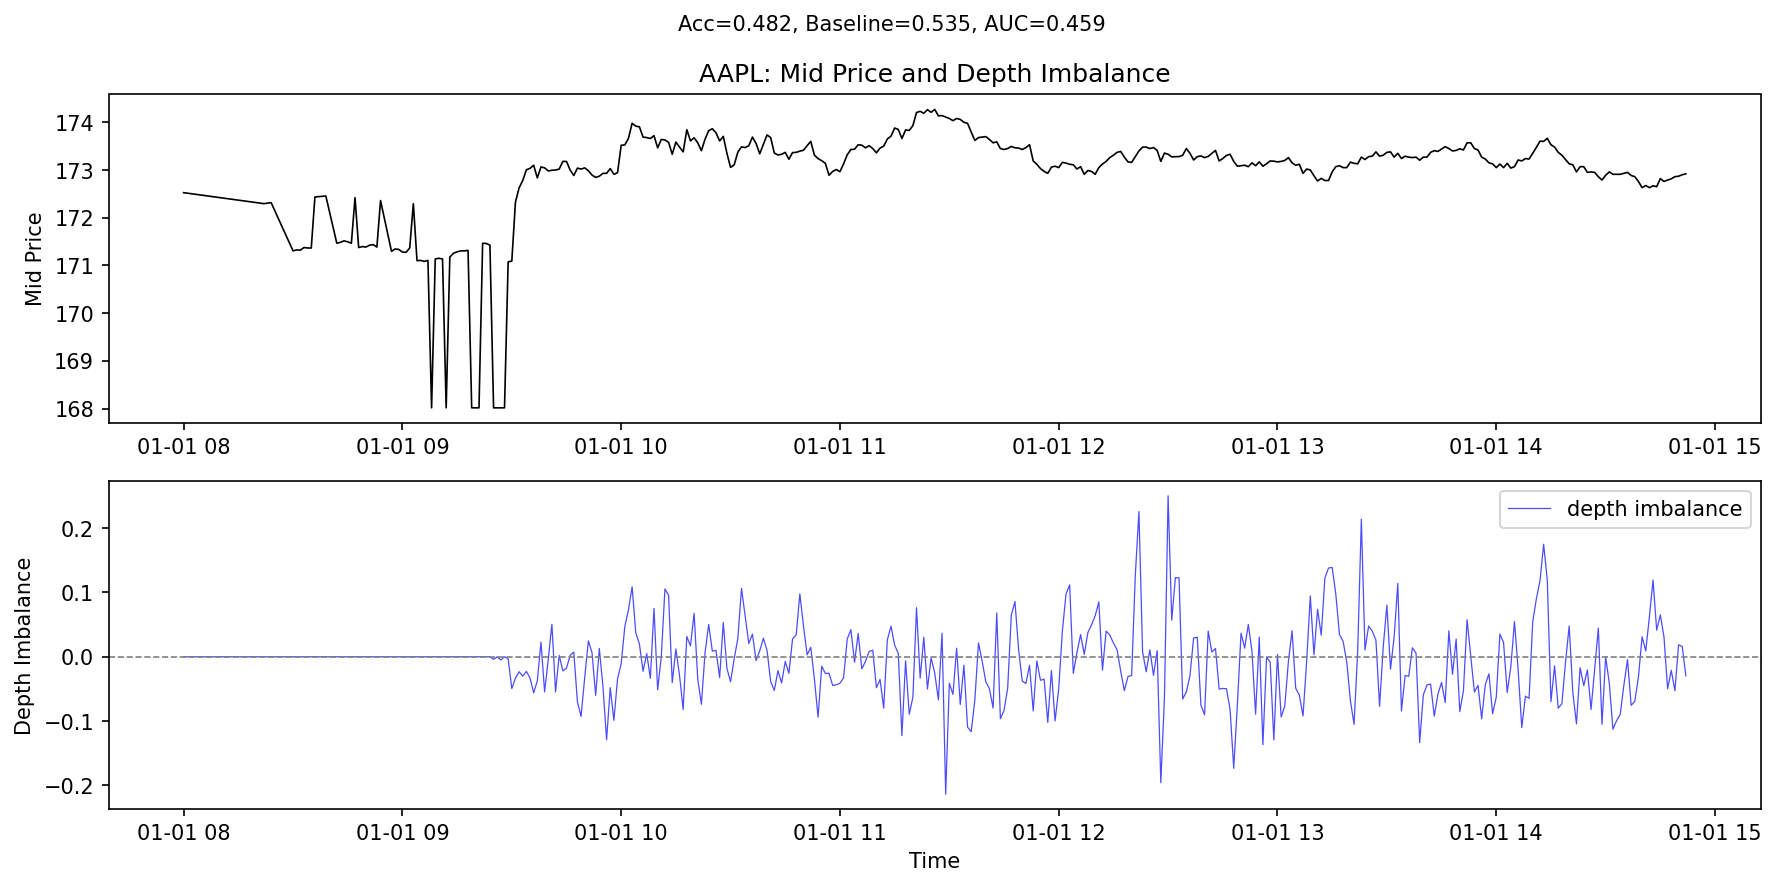


=== DIA — Depth Imbalance Signal ===


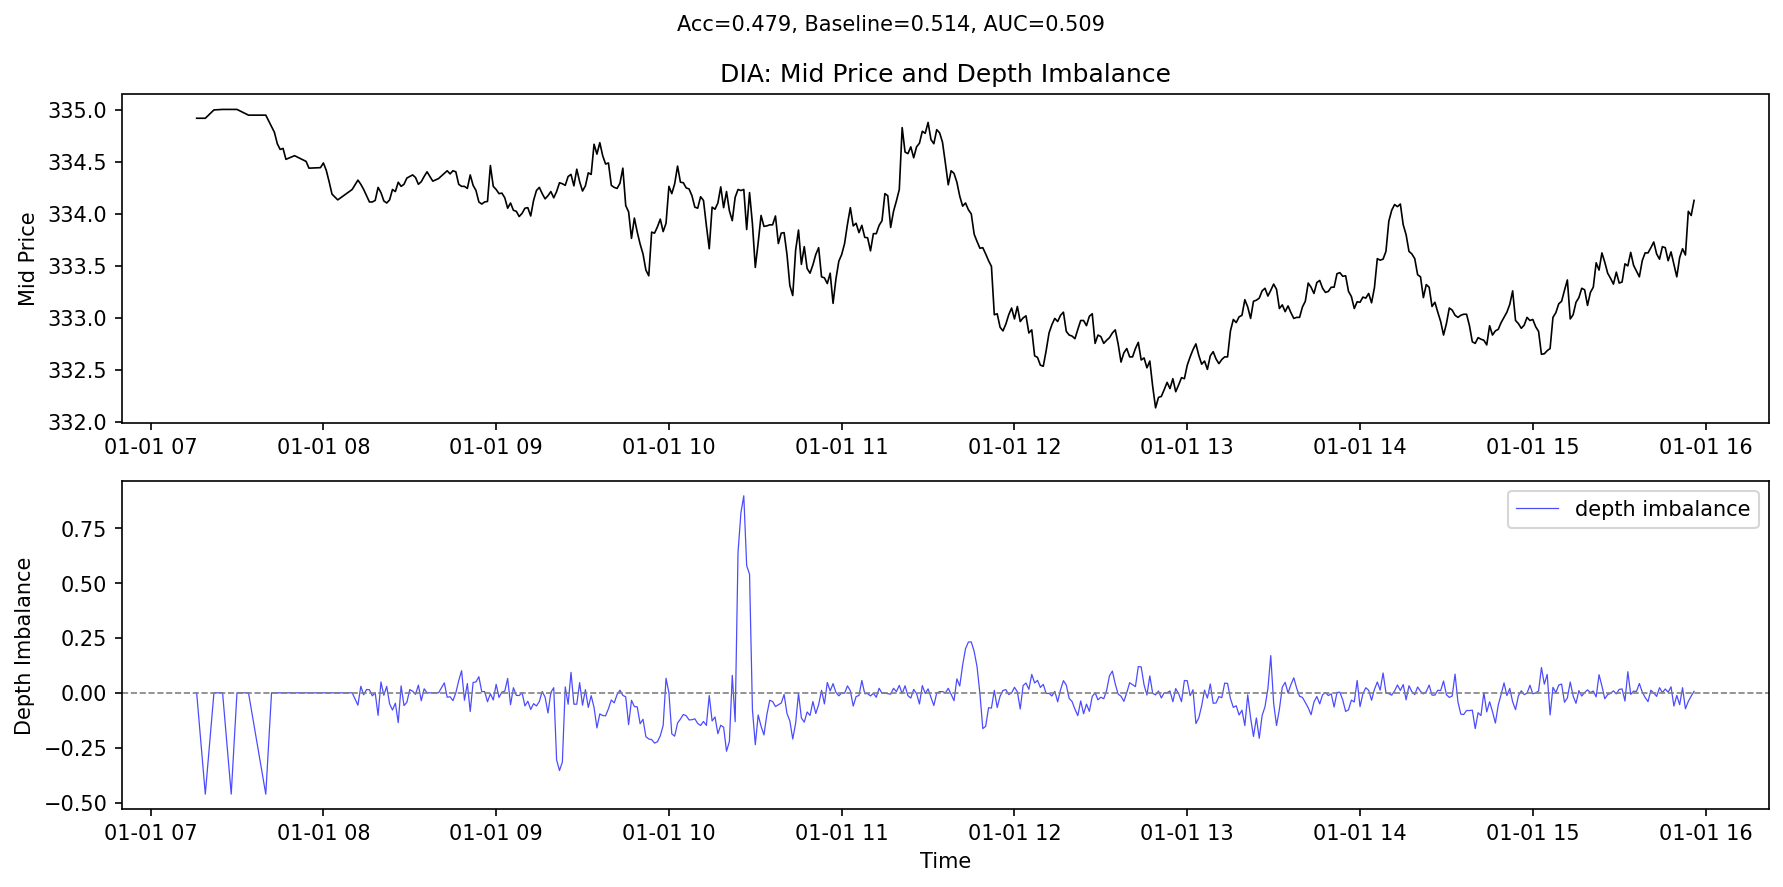


=== IVV — Depth Imbalance Signal ===


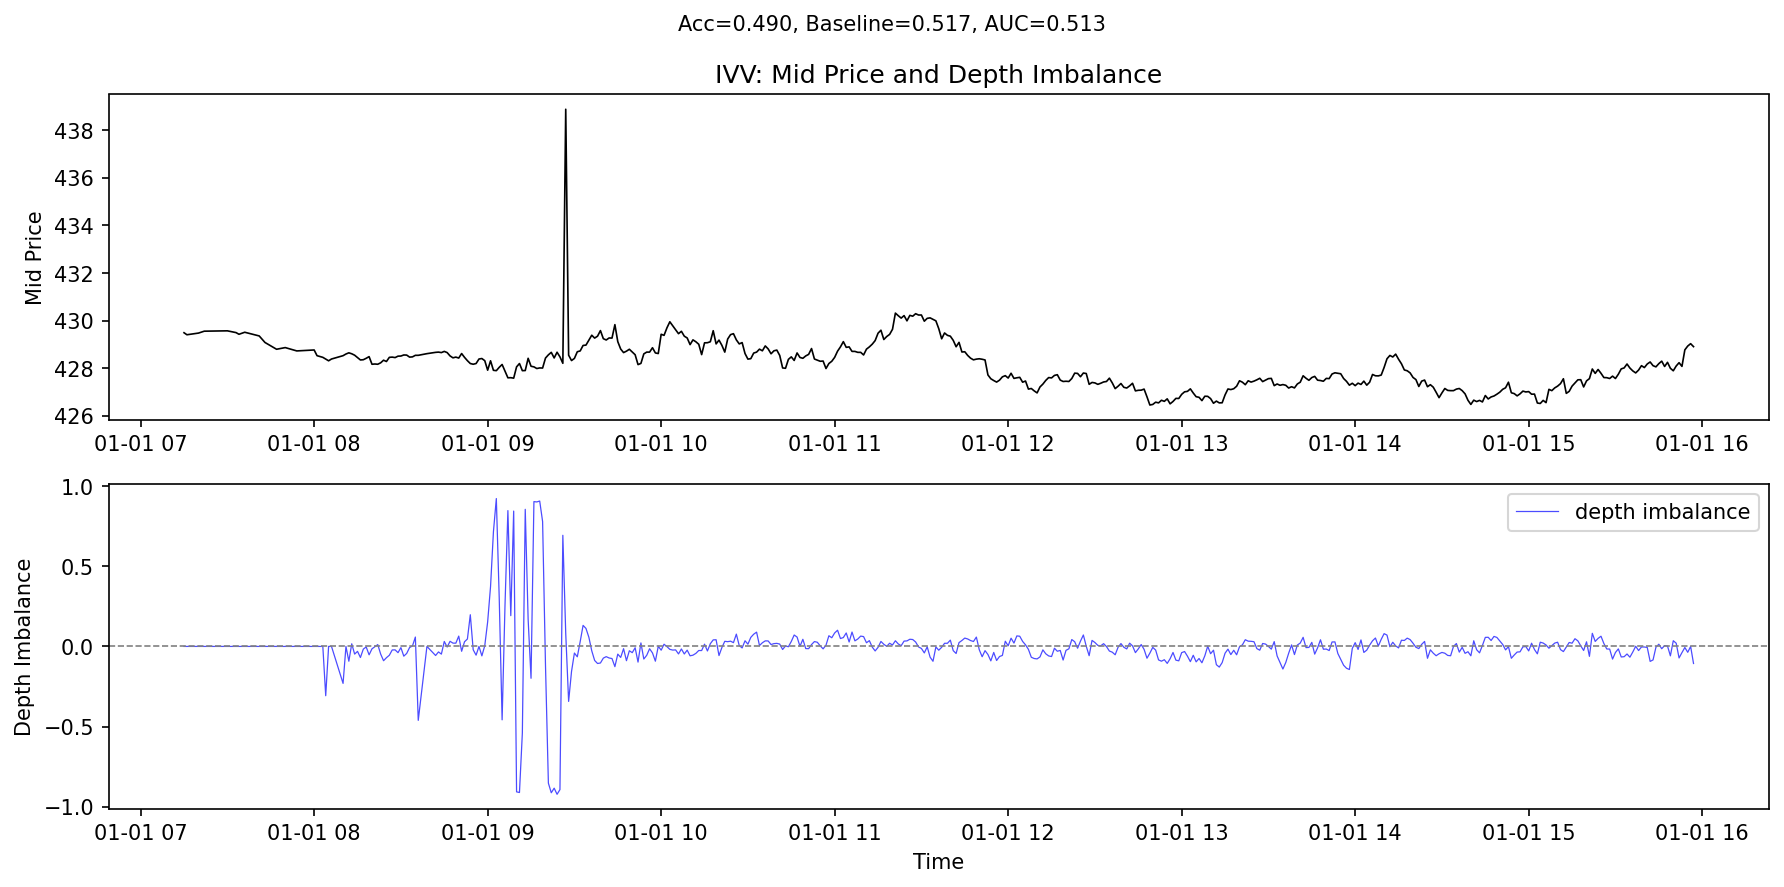


=== IWM — Depth Imbalance Signal ===


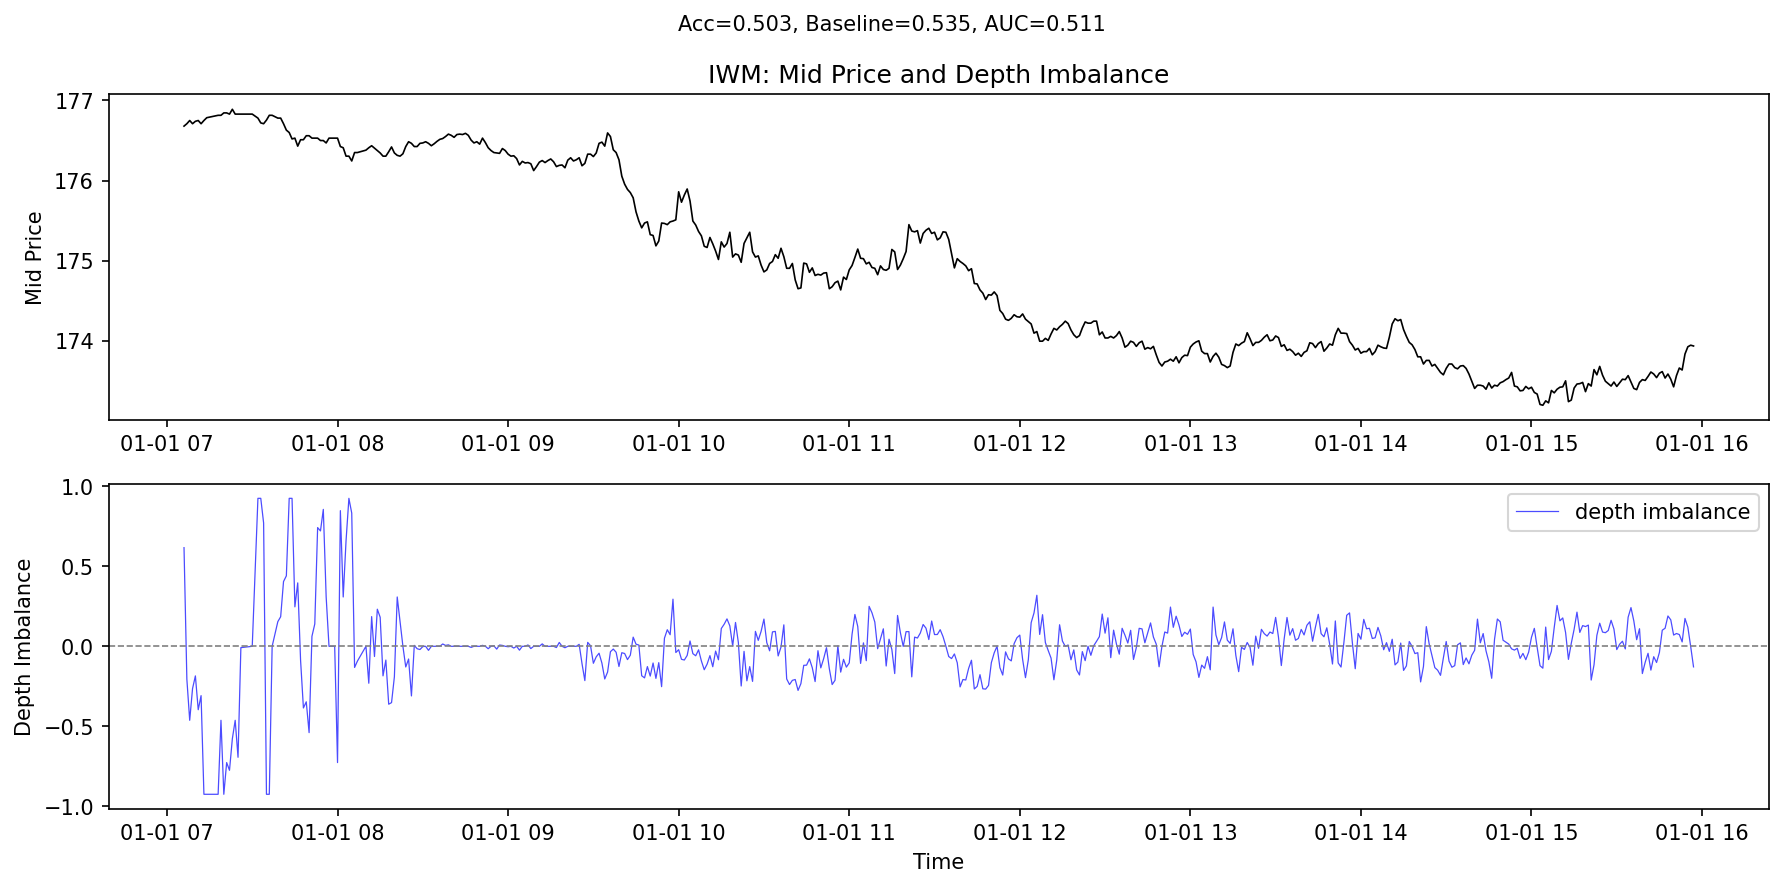


=== GOOGL — Depth Imbalance Signal ===


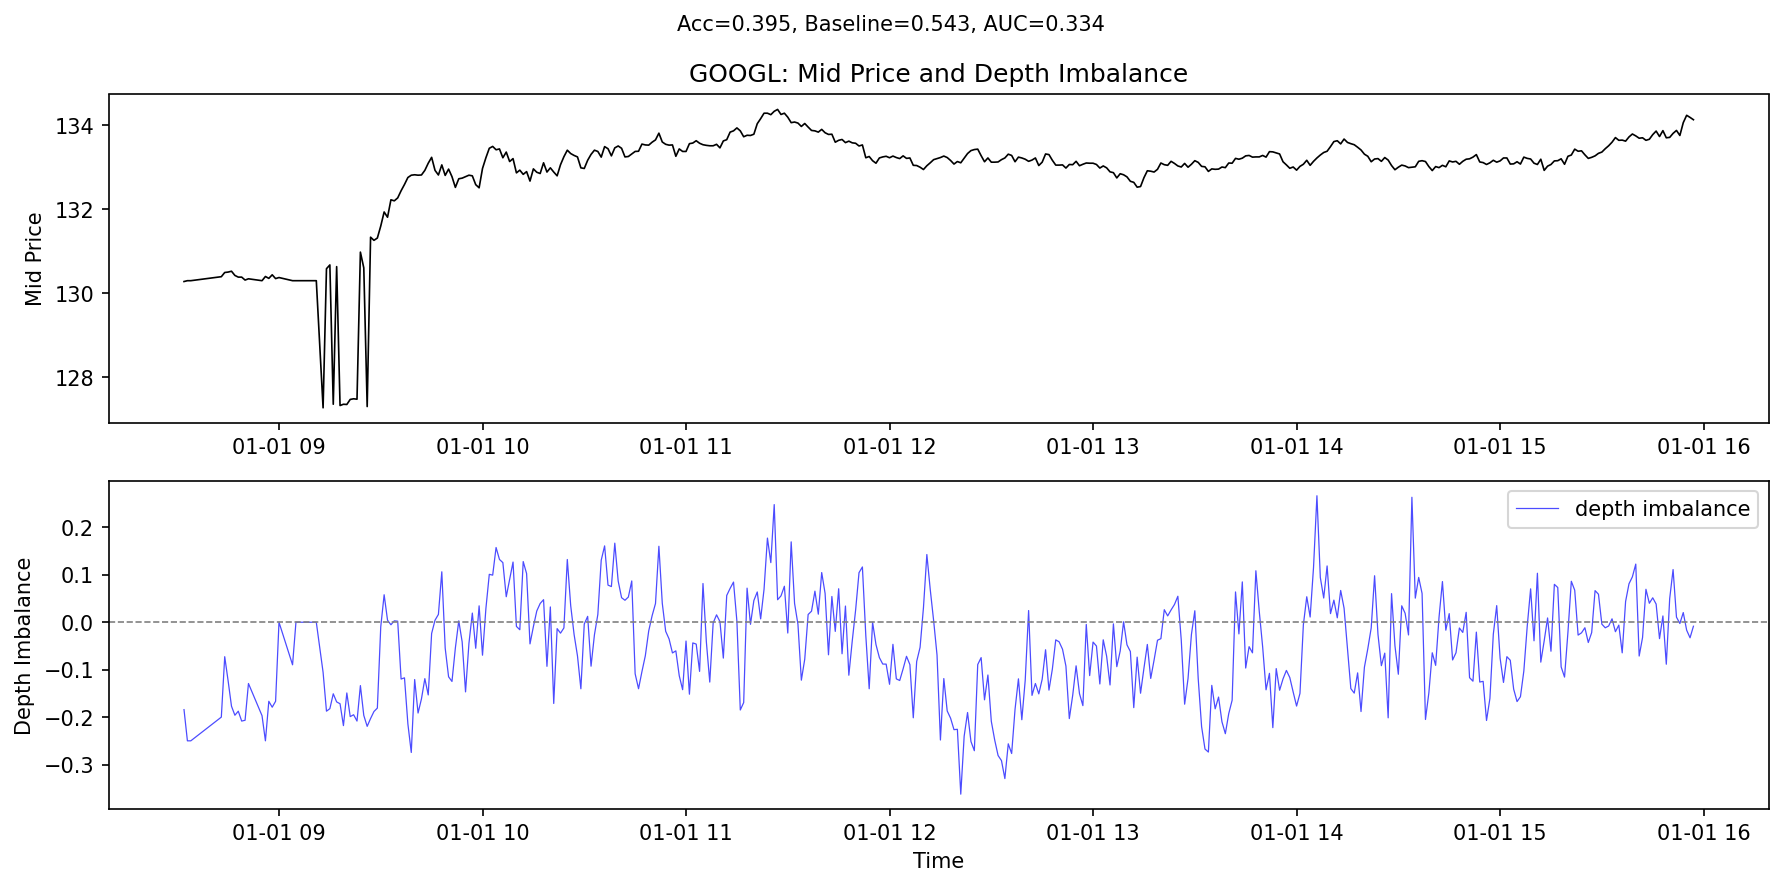


=== AMZN — Depth Imbalance Signal ===


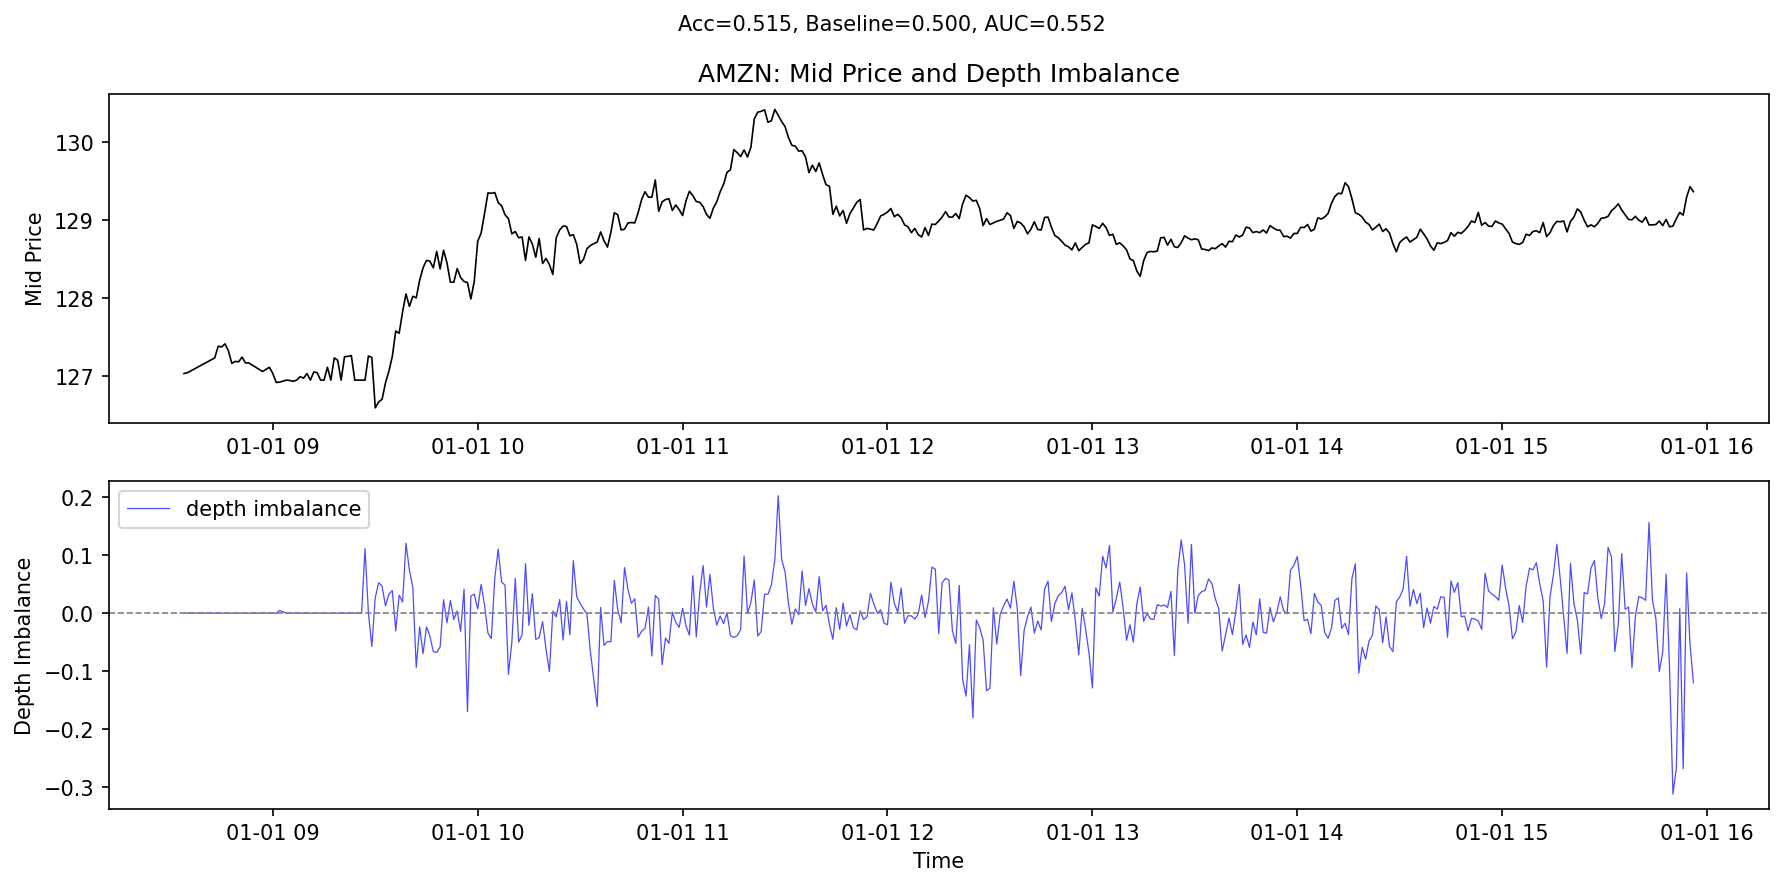

In [13]:
for symbol in ['AAPL', 'DIA', 'IVV', 'IWM', 'GOOGL', 'AMZN']:
    img_path = FOLDER / f'taq_signal_{symbol}.png'
    if img_path.exists():
        print(f'\n=== {symbol} — Depth Imbalance Signal ===')
        display(Image(filename=str(img_path)))

---
## Part 6: Overall Summary and What to Say Tomorrow

### What we have proven

1. **We can parse TAQ data** — both BBO quotes and consolidated trades, pipe-delimited and comma-delimited formats.
2. **We can build standard microstructure features** — spread, depth, volume, VWAP, realized variance, quote intensity.
3. **Features carry some signal** — train R² is positive for volatility prediction, meaning lagged microstructure features do contain information about future volatility.
4. **Signal is weak with limited data** — test R² is negative and directional accuracy is near 50%. This is expected with only 1 hour of BBO data and ~130 test points.

### What we have NOT proven yet

- That nonlinear dimension reduction finds structure PCA misses (need more symbol-days)
- That microstructure features predict returns out-of-sample (need more data)
- That depth imbalance is a profitable trading signal (need transaction cost analysis)

### What to mention in the meeting

**30-second version:**

> I parsed the NYSE TAQ sample data and built one-minute microstructure features — spreads, depth imbalance, quote intensity, volume, VWAP, and realized variance. I also tested whether these features predict near-term volatility and direction. The train R² is positive, meaning there is signal, but with only one hour of data the test performance is unstable. The main research direction is to turn each stock/day into an intraday curve and compare PCA with nonlinear methods like Isomap and UMAP.

**If asked about predictive results:**

> The volatility prediction model gets positive R² on the training set (0.04 to 0.85 across symbols), which confirms that lagged spread, depth, and volatility features carry information. But the test R² is very negative because we only have about 130 test points from one hour of data. With more days, the test performance should stabilize.

**If asked about the signal plots:**

> The depth imbalance signal shows a slight edge for some symbols — AAPL and IWM have directional accuracy above baseline. But it's not consistent across all symbols, and with one hour of data it's hard to distinguish signal from noise.